<h1><b>Door Subsystem Exploratory Data Analysis</b></h1>

<h4><b>Background Information</b></h4>

NEBULA X Problem Statement 3 concerns train condition monitoring. The Door subsystem provides controller streams for identifying opening and closing cycles and distinguishing Normal operation from Abnormal resistance.

<h4><b>Objective</b></h4>

This notebook assesses data quality, verifies cycle and label alignment, and examines signal patterns relevant to resistance detection. The scope is exploratory data analysis; model training and deployment are excluded.

<h4><b>Project Workflow</b></h4>

The workflow establishes the environment, inspects and validates the datasets, examines cycle boundaries and operations, constructs descriptive cycle summaries, compares classes and datasets, and documents findings and limitations.

<h4><b>Dataset Used</b></h4>

The files in `PS3/02_Datasets/Door` are `Train.csv`, `Train_Segments_Answer.csv`, and `Test.csv`. The Train stream contains 18,036 readings and 110 labelled cycles; the Test stream contains 6,253 unlabelled readings. The Door subsystem information kit and parameter documentation define the task and recorded signals.

<h4><b>Table of Contents</b></h4>
<ul>
  <li><a href="#section-1">Section 1: Environment Setup and Configuration</a>
    <ul>
      <li><a href="#1-1">1.1 Imports</a></li>
      <li><a href="#1-2">1.2 Display Settings</a></li>
      <li><a href="#1-3">1.3 Data Paths</a></li>
    </ul>
  </li>
  <li><a href="#section-2">Section 2: Dataset Inventory and Initial Inspection</a>
    <ul>
      <li><a href="#2-1">2.1 Files</a></li>
      <li><a href="#2-2">2.2 Loading</a></li>
      <li><a href="#2-3">2.3 Row and Column Counts</a></li>
      <li><a href="#2-4">2.4 Time Coverage</a></li>
      <li><a href="#2-5">2.5 Stream Preview</a></li>
    </ul>
  </li>
  <li><a href="#section-3">Section 3: Schema and Data Type Validation</a>
    <ul>
      <li><a href="#3-1">3.1 Column Agreement</a></li>
      <li><a href="#3-2">3.2 Documented Parameters</a></li>
      <li><a href="#3-3">3.3 Data Types</a></li>
      <li><a href="#3-4">3.4 Timestamp Round Trip</a></li>
    </ul>
  </li>
  <li><a href="#section-4">Section 4: Data Quality Assessment</a>
    <ul>
      <li><a href="#4-1">4.1 Missing Values</a></li>
      <li><a href="#4-2">4.2 Duplicates and Ordering</a></li>
      <li><a href="#4-3">4.3 Sampling Interval</a></li>
      <li><a href="#4-4">4.4 Logging Pauses</a></li>
      <li><a href="#4-5">4.5 Constant Columns</a></li>
      <li><a href="#4-6">4.6 Discrete Value Domains</a></li>
      <li><a href="#4-7">4.7 Continuous Value Ranges</a></li>
      <li><a href="#4-8">4.8 Controller Timing Values</a></li>
      <li><a href="#4-9">4.9 Outlier Screen</a></li>
    </ul>
  </li>
  <li><a href="#section-5">Section 5: Signal Distributions</a>
    <ul>
      <li><a href="#5-1">5.1 Summary Statistics</a></li>
      <li><a href="#5-2">5.2 Continuous Columns</a></li>
      <li><a href="#5-3">5.3 Discrete Columns</a></li>
    </ul>
  </li>
  <li><a href="#section-6">Section 6: Label Integrity and Coverage</a>
    <ul>
      <li><a href="#6-1">6.1 Answer File Consistency</a></li>
      <li><a href="#6-2">6.2 Label Counts</a></li>
      <li><a href="#6-3">6.3 Row Coverage</a></li>
      <li><a href="#6-4">6.4 Stated Row Counts</a></li>
    </ul>
  </li>
  <li><a href="#section-7">Section 7: Cycle Boundary Assessment</a>
    <ul>
      <li><a href="#7-1">7.1 Gap-Delimited Runs</a></li>
      <li><a href="#7-2">7.2 Agreement With the Answers</a></li>
      <li><a href="#7-3">7.3 Boundary Overlap</a></li>
      <li><a href="#7-4">7.4 Run Lengths</a></li>
    </ul>
  </li>
  <li><a href="#section-8">Section 8: Operation Identification</a>
    <ul>
      <li><a href="#8-1">8.1 Indicator Columns</a></li>
      <li><a href="#8-2">8.2 Operation Rule</a></li>
      <li><a href="#8-3">8.3 Position Travel</a></li>
      <li><a href="#8-4">8.4 Operation Order</a></li>
      <li><a href="#8-5">8.5 Cycle Length by Operation</a></li>
    </ul>
  </li>
  <li><a href="#section-9">Section 9: Within-Cycle Signal Analysis</a>
    <ul>
      <li><a href="#9-1">9.1 Row Context</a></li>
      <li><a href="#9-2">9.2 Example Cycles</a></li>
      <li><a href="#9-3">9.3 Median Current Profiles</a></li>
      <li><a href="#9-4">9.4 Current Against Door Position</a></li>
      <li><a href="#9-5">9.5 Timing Column Updates</a></li>
    </ul>
  </li>
  <li><a href="#section-10">Section 10: Normal and Abnormal Resistance Comparison</a>
    <ul>
      <li><a href="#10-1">10.1 Cycle Features</a></li>
      <li><a href="#10-2">10.2 Class Means</a></li>
      <li><a href="#10-3">10.3 Single-Feature Separability</a></li>
      <li><a href="#10-4">10.4 Mean Current by Class</a></li>
      <li><a href="#10-5">10.5 Class Margin</a></li>
    </ul>
  </li>
  <li><a href="#section-11">Section 11: Train and Test Distribution Comparison</a>
    <ul>
      <li><a href="#11-1">11.1 Test Cycle Features</a></li>
      <li><a href="#11-2">11.2 Test Cycles Against Train Classes</a></li>
      <li><a href="#11-3">11.3 Position Against the Train Margins</a></li>
      <li><a href="#11-4">11.4 Zeroed Timing Values in Test</a></li>
      <li><a href="#11-5">11.5 Position Travel in Test</a></li>
      <li><a href="#11-6">11.6 Profiles of Between-Range Test Cycles</a></li>
      <li><a href="#11-7">11.7 Current by Cycle Phase</a></li>
    </ul>
  </li>
  <li><a href="#section-12">Section 12: Extended Cycle-Level Analysis</a>
    <ul>
      <li><a href="#12-1">12.1 Boundary Sensitivity and Label Alignment</a></li>
      <li><a href="#12-2">12.2 Motion, Electrical Load, and Controller Consistency</a></li>
      <li><a href="#12-3">12.3 Cycle Distributions and Feature Redundancy</a></li>
      <li><a href="#12-4">12.4 Contextual Outlier Screening</a></li>
      <li><a href="#12-5">12.5 Flagged Test Trace Inspection</a></li>
      <li><a href="#12-6">12.6 Quantified Train and Test Shift</a></li>
      <li><a href="#12-7">12.7 Repeated Cycles and Recording-Order Confounding</a></li>
      <li><a href="#12-8">12.8 Uncertainty in Class Differences</a></li>
    </ul>
  </li>
  <li><a href="#section-13">Section 13: Findings and Conclusions</a>
    <ul>
      <li><a href="#13-1">13.1 Data Quality</a></li>
      <li><a href="#13-2">13.2 Labels and Cycle Boundaries</a></li>
      <li><a href="#13-3">13.3 Operation and Cycle Behaviour</a></li>
      <li><a href="#13-4">13.4 Class Differences</a></li>
      <li><a href="#13-5">13.5 Train and Test Shift</a></li>
      <li><a href="#13-6">13.6 Implications for Modelling</a></li>
      <li><a href="#13-7">13.7 Extended Analysis Findings</a></li>
    </ul>
  </li>
  <li><a href="#section-14">Section 14: EDA Limitations and Modelling Handoff</a>
  </li>
</ul>

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-1" style="color: black;"><b>Section 1: Environment Setup and Configuration</b></h2>
</div>

This section imports the analysis libraries, defines the local data helpers, and configures display settings and dataset paths.

<blockquote><h3 id="1-1"><b>1.1 Imports</b></h3></blockquote>

The following cell imports the analysis libraries and defines self-contained loading, timestamp, cycle, and plotting helpers so that the notebook runs without the external `tfd` package.

In [1]:
import os
from pathlib import Path
from types import SimpleNamespace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from IPython.display import display

# Self-contained replacements for the original project's unavailable tfd helpers.
def find_door_dir():
    if os.environ.get('TFD_PS3_DIR'):
        root = Path(os.environ['TFD_PS3_DIR']).expanduser()
        candidates = [root / '02_Datasets' / 'Door']
    else:
        candidates = [p / q for p in [Path.cwd(), *Path.cwd().parents]
                      for q in ['PS3/02_Datasets/Door', '02_Datasets/Door']]
    for p in candidates:
        if (p / 'Train.csv').is_file(): return p.resolve()
    raise FileNotFoundError('Run from this repository or set TFD_PS3_DIR to the PS3 folder.')

def parse_native(s):
    parts = s.str.split('-', expand=True).astype(int)
    if parts.shape[1] != 7: raise ValueError('Expected seven timestamp fields')
    base = pd.to_datetime(dict(zip(['year','month','day','hour','minute','second'],
                                   [parts[i] for i in range(6)])))
    return base + pd.to_timedelta(parts[6], unit='ms')

def load_stream(path):
    frame = pd.read_csv(path)
    frame.insert(0, 'time', parse_native(frame['Datetime']))
    return frame

def load_segments(path):
    frame = pd.read_csv(path)
    frame['start'] = parse_native(frame['start_time'])
    frame['end'] = parse_native(frame['end_time'])
    frame.index = pd.RangeIndex(len(frame), name='cycle')
    return frame

def split_cycles(time):
    return time.diff().gt(pd.Timedelta(milliseconds=20)).cumsum().rename('cycle')

def cycle_table(stream):
    return stream.groupby(split_cycles(stream['time']))['time'].agg(start='first', end='last', n_rows='size')

door = SimpleNamespace(
    TIME='Datetime', CURRENT='Motor current(mA)', VOLTAGE='Motor Voltage(10mV)',
    BACK_EMF='Motor electrodynamic force', POSITION='Door leaf position',
    OPEN_TIME='Door opening time(.1s)', CLOSE_TIME='Door closing time(.1s)',
    COMMANDS=['Close command','Open command'], SWITCHES=['DCSR','DCSL','DLSR','DLSL'],
    FLAGS=['Door Opened','Door Locked','Door is opening','Door is closing'],
    door_dir=find_door_dir, load_stream=load_stream, load_segments=load_segments,
    split_cycles=split_cycles, cycle_table=cycle_table)
door.ANALOGUE = [door.CURRENT, door.VOLTAGE, door.BACK_EMF, door.POSITION]
door.TIMING = [door.OPEN_TIME, door.CLOSE_TIME]
viz = SimpleNamespace(CLASS_COLORS={'Normal':'#16857b','Abnormal resistance':'#d95f38'},
    SERIES=['#2878a5'], MUTED='#777777', TEST_COLOR='#8256b3', SURFACE='white',
    apply_style=lambda: plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False,
                                            'axes.spines.right':False, 'figure.constrained_layout.use':True}))


<blockquote><h3 id="1-2"><b>1.2 Display Settings</b></h3></blockquote>

Figures use the shared notebook style, and tables are allowed to show every column.

In [2]:
viz.apply_style()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

<blockquote><h3 id="1-3"><b>1.3 Data Paths</b></h3></blockquote>

Dataset paths are discovered from the repository root or the `PS3` directory. The `TFD_PS3_DIR` environment variable supports another PS3 location. The selected Python environment requires the packages in `door_eda_requirements.txt`.

In [3]:
DOOR_DIR = door.door_dir()
TRAIN_CSV = DOOR_DIR / "Train.csv"
TEST_CSV = DOOR_DIR / "Test.csv"
ANSWERS_CSV = DOOR_DIR / "Train_Segments_Answer.csv"
DOOR_DIR

WindowsPath('C:/Users/user/OneDrive - Singapore Polytechnic/NebulaX-Hackathon-ProblemStatement/PS3/02_Datasets/Door')

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-2" style="color: black;"><b>Section 2: Dataset Inventory and Initial Inspection</b></h2>
</div>

This section inventories the source files, loads the streams and segment labels, and inspects dataset dimensions, time coverage, and sample rows.

<blockquote><h3 id="2-1"><b>2.1 Files</b></h3></blockquote>

The Door folder is expected to hold three files: the labelled Train stream, its segment answers,
and the unlabelled Test stream.

In [4]:
pd.DataFrame(
    [(p.name, p.stat().st_size / 1e6) for p in sorted(DOOR_DIR.iterdir())],
    columns=["file", "size_mb"],
).round(2)

,file,size_mb
0,Test.csv,0.40
1,Train.csv,1.16
2,Train_Segments_Answer.csv,0.01


<blockquote><h3 id="2-2"><b>2.2 Loading</b></h3></blockquote>

Both streams are read with a parsed `time` column placed in front of the raw `Datetime` string.
The segment answers gain parsed `start` and `end` columns.

In [5]:
train = door.load_stream(TRAIN_CSV)
test = door.load_stream(TEST_CSV)
answers = door.load_segments(ANSWERS_CSV)

<blockquote><h3 id="2-3"><b>2.3 Row and Column Counts</b></h3></blockquote>

The following table reports row and column counts for both streams and the segment answers to establish their dimensions after loading.

In [6]:
pd.DataFrame(
    {
        "rows": [len(train), len(test), len(answers)],
        "columns": [train.shape[1], test.shape[1], answers.shape[1]],
    },
    index=["train", "test", "answers"],
)

,rows,columns
train,18036,18
test,6253,18
answers,110,8


<blockquote><h3 id="2-4"><b>2.4 Time Coverage</b></h3></blockquote>

The first and last timestamps of each stream give the recorded span.

In [7]:
pd.DataFrame(
    {
        "start": [train["time"].min(), test["time"].min()],
        "end": [train["time"].max(), test["time"].max()],
    },
    index=["train", "test"],
).assign(span=lambda d: d["end"] - d["start"])

,start,end,span
train,2023-07-05,2023-07-05 01:10:17.112,0 days 01:10:17.112000
test,2023-07-05,2023-07-05 00:23:49.544,0 days 00:23:49.544000


<blockquote><h3 id="2-5"><b>2.5 Stream Preview</b></h3></blockquote>

The first Train rows are displayed to inspect representative timestamps, signal values, and column names.

In [8]:
train.head()

,time,Datetime,Motor current(mA),Motor Voltage(10mV),Motor electrodynamic force,Door opening time(.1s),Door closing time(.1s),Close command,Open command,DCSR,DCSL,DLSR,DLSL,Door Opened,Door Locked,Door is opening,Door is closing,Door leaf position
0,2023-07-05 00:00:00.000,2023-7-5-0-0-0-0,115,400,53,24,35,1,0,0,0,0,0,0,0,0,1,700
1,2023-07-05 00:00:00.020,2023-7-5-0-0-0-20,132,600,93,24,35,1,0,0,0,0,0,0,0,0,1,700
2,2023-07-05 00:00:00.040,2023-7-5-0-0-0-40,176,700,108,24,35,1,0,0,0,0,0,0,0,0,1,700
3,2023-07-05 00:00:00.060,2023-7-5-0-0-0-60,317,1000,114,24,35,1,0,0,0,0,0,0,0,0,1,699
4,2023-07-05 00:00:00.080,2023-7-5-0-0-0-80,503,1500,150,24,35,1,0,0,0,0,0,0,0,0,1,699


<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-3" style="color: black;"><b>Section 3: Schema and Data Type Validation</b></h2>
</div>

This section compares recorded columns with the documented schema, inspects data types, and checks timestamp parsing for information loss.

<blockquote><h3 id="3-1"><b>3.1 Column Agreement</b></h3></blockquote>

The Train and Test streams should share one column list in the same order.

In [9]:
pd.Series(
    {
        "same columns and order": list(train.columns) == list(test.columns),
        "only in train": sorted(set(train.columns) - set(test.columns)),
        "only in test": sorted(set(test.columns) - set(train.columns)),
    }
)

same columns and order    True
only in train               []
only in test                []
dtype: object

<blockquote><h3 id="3-2"><b>3.2 Documented Parameters</b></h3></blockquote>

The parameter list in `Door Data Headers.md` is matched by meaning against the recorded column
names, which are spelled differently. Parameters without a recorded column are marked absent.

In [10]:
DOCUMENTED = {
    "Datetime": door.TIME,
    "Car Type": None,
    "Car Number": None,
    "Door Number": None,
    "Motor current (mA)": door.CURRENT,
    "Motor Voltage (10mV)": door.VOLTAGE,
    "Motor back electromotive force": door.BACK_EMF,
    "Door opening time (0.1 s)": door.OPEN_TIME,
    "Door closing time (0.1 s)": door.CLOSE_TIME,
    "Close command": "Close command",
    "Open command": "Open command",
    "DCSR": "DCSR",
    "DCSL": "DCSL",
    "DLSR": "DLSR",
    "DLSL": "DLSL",
    "Door Opened": "Door Opened",
    "Door Locked": "Door Locked",
    "Door is opening": "Door is opening",
    "Door is closing": "Door is closing",
    "Door leaf position": door.POSITION,
}

The documented parameter mapping is compared with the recorded columns to identify available and absent fields.

In [11]:
pd.DataFrame({"recorded_as": pd.Series(DOCUMENTED)}).assign(
    present=lambda d: d["recorded_as"].isin(train.columns)
)

,recorded_as,present
Datetime,Datetime,True
Car Type,NaN,False
Car Number,NaN,False
Door Number,NaN,False
Motor current (mA),Motor current(mA),True
Motor Voltage (10mV),Motor Voltage(10mV),True
Motor back electromotive force,Motor electrodynamic force,True
Door opening time (0.1 s),Door opening time(.1s),True
Door closing time (0.1 s),Door closing time(.1s),True
Close command,Close command,True


<blockquote><h3 id="3-3"><b>3.3 Data Types</b></h3></blockquote>

The Train and Test data types are displayed side by side to identify schema inconsistencies before numerical analysis.

In [12]:
pd.DataFrame({"train": train.dtypes.astype(str), "test": test.dtypes.astype(str)})

,train,test
time,datetime64[us],datetime64[us]
Datetime,str,str
Motor current(mA),int64,int64
Motor Voltage(10mV),int64,int64
Motor electrodynamic force,int64,int64
Door opening time(.1s),int64,int64
Door closing time(.1s),int64,int64
Close command,int64,int64
Open command,int64,int64
DCSR,int64,int64


<blockquote><h3 id="3-4"><b>3.4 Timestamp Round Trip</b></h3></blockquote>

Timestamps use unpadded, hyphen-separated fields with milliseconds last, for example
`2023-7-5-0-0-3-760`. Formatting the parsed values back into this style and comparing them with
the raw strings confirms that parsing lost no information.

In [13]:
def to_native(time: pd.Series) -> pd.Series:
    """Format datetimes in the dataset's unpadded Year-Month-Day-Hour-Minute-Second-Millisecond style."""
    t = time.dt
    fields = [t.year, t.month, t.day, t.hour, t.minute, t.second, t.microsecond // 1000]
    return pd.concat([f.astype(str) for f in fields], axis=1).agg("-".join, axis=1)

The timestamp formatter is applied to both streams and the answer boundaries. Exact string agreement checks whether parsing preserved the native timestamp values.

In [14]:
pd.Series(
    {
        "train Datetime": (to_native(train["time"]) == train[door.TIME]).mean(),
        "test Datetime": (to_native(test["time"]) == test[door.TIME]).mean(),
        "answers start_time": (to_native(answers["start"]) == answers["start_time"]).mean(),
        "answers end_time": (to_native(answers["end"]) == answers["end_time"]).mean(),
    },
    name="share_matching",
)

train Datetime        1.0
test Datetime         1.0
answers start_time    1.0
answers end_time      1.0
Name: share_matching, dtype: float64

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-4" style="color: black;"><b>Section 4: Data Quality Assessment</b></h2>
</div>

This section checks missing values, duplicates, timestamp ordering, sampling intervals, and value domains before deeper signal analysis.

<blockquote><h3 id="4-1"><b>4.1 Missing Values</b></h3></blockquote>

Missing cells are counted in each dataset to determine whether incomplete records require further investigation.

In [15]:
pd.Series(
    {
        "train": int(train.isna().sum().sum()),
        "test": int(test.isna().sum().sum()),
        "answers": int(answers.isna().sum().sum()),
    },
    name="missing_cells",
)

train      0
test       0
answers    0
Name: missing_cells, dtype: int64

<blockquote><h3 id="4-2"><b>4.2 Duplicates and Ordering</b></h3></blockquote>

Duplicate rows, repeated timestamps, and monotonic timestamp ordering are checked to assess record uniqueness and sequence integrity.

In [16]:
pd.DataFrame(
    {
        "duplicate_rows": [train.duplicated().sum(), test.duplicated().sum()],
        "duplicate_timestamps": [train["time"].duplicated().sum(), test["time"].duplicated().sum()],
        "time_increasing": [train["time"].is_monotonic_increasing, test["time"].is_monotonic_increasing],
    },
    index=["train", "test"],
)

,duplicate_rows,duplicate_timestamps,time_increasing
train,0,0,True
test,0,0,True


<blockquote><h3 id="4-3"><b>4.3 Sampling Interval</b></h3></blockquote>

The step between consecutive rows shows whether sampling is uniform. Steps are grouped into those
equal to 20 ms and those shorter or longer.

In [17]:
def step_ms(time: pd.Series) -> pd.Series:
    """Milliseconds between consecutive timestamps, excluding the first row."""
    return time.diff().dt.total_seconds().mul(1000).dropna()

Sampling intervals are grouped around the expected 20 ms interval, allowing shorter intervals and logging gaps to be counted separately.

In [18]:
STEP_BINS = [-np.inf, 19.5, 20.5, np.inf]
STEP_LABELS = ["under 20 ms", "20 ms", "over 20 ms"]
pd.DataFrame(
    {
        name: pd.cut(step_ms(df["time"]), STEP_BINS, labels=STEP_LABELS).value_counts()
        for name, df in [("train", train), ("test", test)]
    }
)

,train,test
time,,
20 ms,17926,6215
over 20 ms,109,37
under 20 ms,0,0


<blockquote><h3 id="4-4"><b>4.4 Logging Pauses</b></h3></blockquote>

Steps longer than 20 ms are pauses in logging. Their lengths are summarised in seconds.

In [19]:
pauses = {
    name: step_ms(df["time"]).loc[lambda s: s > 20].div(1000)
    for name, df in [("train", train), ("test", test)]
}
pd.DataFrame({name: s.describe() for name, s in pauses.items()}).round(1)

,train,test
count,109.0,37.0
mean,35.4,35.3
std,14.0,12.8
min,10.2,11.1
25%,24.3,26.1
50%,37.0,37.8
75%,46.9,44.6
max,58.8,55.4


Histograms compare the lengths of logging pauses in Train and Test to show the distribution of gaps between recorded runs.

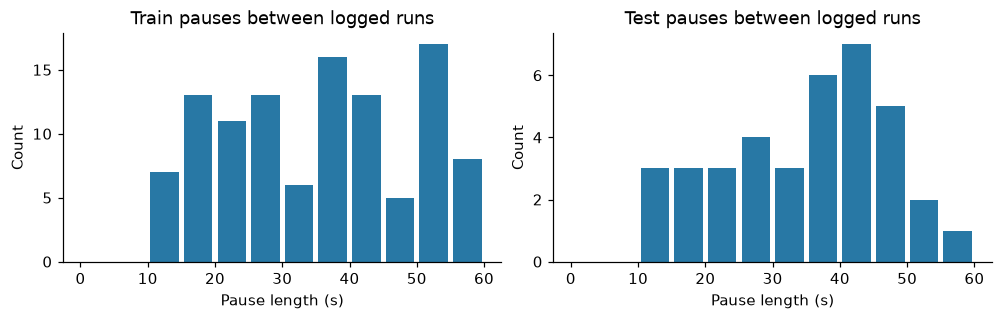

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(9, 2.8), sharex=True)
for ax, (name, s) in zip(axes, pauses.items()):
    ax.hist(s, bins=np.arange(0, 65, 5), color=viz.SERIES[0], rwidth=0.85)
    ax.set(title=f"{name.title()} pauses between logged runs", xlabel="Pause length (s)", ylabel="Count")
plt.show()

<blockquote><h3 id="4-5"><b>4.5 Constant Columns</b></h3></blockquote>

Columns with a single distinct value carry no information in that stream.

In [21]:
pd.DataFrame({"train_unique": train.nunique(), "test_unique": test.nunique()}).query(
    "train_unique <= 1 or test_unique <= 1"
)

,train_unique,test_unique
Door Locked,1,1


<blockquote><h3 id="4-6"><b>4.6 Discrete Value Domains</b></h3></blockquote>

Commands, switches and state flags are expected to be binary. The distinct values of each column
are listed per stream.

In [22]:
DISCRETE = door.COMMANDS + door.SWITCHES + door.FLAGS


def value_set(s: pd.Series) -> str:
    """Sorted distinct values of a column as one comma-separated string."""
    return ", ".join(str(v) for v in sorted(s.unique().tolist()))

The distinct values of each command, switch, and state flag are compared between streams to screen for non-binary or inconsistent domains.

In [23]:
pd.DataFrame(
    {
        "train": {c: value_set(train[c]) for c in DISCRETE},
        "test": {c: value_set(test[c]) for c in DISCRETE},
    }
)

,train,test
Close command,"0, 1","0, 1"
Open command,"0, 1","0, 1"
DCSR,"0, 1","0, 1"
DCSL,"0, 1","0, 1"
DLSR,"0, 1","0, 1"
DLSL,"0, 1","0, 1"
Door Opened,"0, 1","0, 1"
Door Locked,0,0
Door is opening,"0, 1","0, 1"
Door is closing,"0, 1","0, 1"


<blockquote><h3 id="4-7"><b>4.7 Continuous Value Ranges</b></h3></blockquote>

Minimum and maximum readings screen for unusual ranges. The documentation does not specify hard physical limits or a position unit; a value outside the training range is not automatically impossible.

In [24]:
CONTINUOUS = door.ANALOGUE + door.TIMING
pd.concat(
    {name: df[CONTINUOUS].agg(["min", "max"]).T for name, df in [("train", train), ("test", test)]},
    axis=1,
)

train        test       
                             min    max  min    max
Motor current(mA)              0   2560    0   2507
Motor Voltage(10mV)          200  10500  200  10400
Motor electrodynamic force     0   2329    0   2418
Door leaf position             0    705    0    807
Door opening time(.1s)        23     25    0     32
Door closing time(.1s)        32     36    0     36

<blockquote><h3 id="4-8"><b>4.8 Controller Timing Values</b></h3></blockquote>

The opening and closing time columns report the controller's measured stroke durations in tenths
of a second. Their value counts are compared between the streams.

In [25]:
pd.concat(
    {name: df[door.OPEN_TIME].value_counts().sort_index() for name, df in [("train", train), ("test", test)]},
    axis=1,
).fillna(0).astype(int).sort_index()

,train,test
Door opening time(.1s),,
0,0,173
22,0,1126
23,7693,2089
24,9862,2384
25,481,296
32,0,185


Closing-time value counts are compared between Train and Test to identify differences in the controller timing domain.

In [26]:
pd.concat(
    {name: df[door.CLOSE_TIME].value_counts().sort_index() for name, df in [("train", train), ("test", test)]},
    axis=1,
).fillna(0).astype(int).sort_index()

,train,test
Door closing time(.1s),,
0,0,346
32,167,1106
33,641,496
34,3911,1094
35,13172,3033
36,145,178


<blockquote><h3 id="4-9"><b>4.9 Outlier Screen</b></h3></blockquote>

Values more than 1.5 interquartile ranges beyond the quartiles are counted per column. Motor
start-up transients make some flagged values expected, so the counts direct inspection rather than
removal.

In [27]:
def iqr_outliers(s: pd.Series) -> int:
    """Count values outside [Q1 - 1.5 IQR, Q3 + 1.5 IQR]."""
    q1, q3 = s.quantile([0.25, 0.75])
    fence = 1.5 * (q3 - q1)
    return int(((s < q1 - fence) | (s > q3 + fence)).sum())

The interquartile-range screen is applied to each continuous column in both streams to count readings that warrant contextual inspection.

In [28]:
pd.DataFrame({name: df[CONTINUOUS].apply(iqr_outliers) for name, df in [("train", train), ("test", test)]})

,train,test
Motor current(mA),2453,906
Motor Voltage(10mV),0,0
Motor electrodynamic force,0,0
Door leaf position,0,0
Door opening time(.1s),0,358
Door closing time(.1s),167,346


<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-5" style="color: black;"><b>Section 5: Signal Distributions</b></h2>
</div>

This section summarises continuous and discrete signals and compares their distributions across the Train and Test streams.

<blockquote><h3 id="5-1"><b>5.1 Summary Statistics</b></h3></blockquote>

Means, standard deviations, and quartiles summarise the scale and spread of continuous readings in each stream.

In [29]:
pd.concat(
    {
        name: df[CONTINUOUS].describe().T[["mean", "std", "25%", "50%", "75%"]]
        for name, df in [("train", train), ("test", test)]
    },
    axis=1,
).round(1)

train                                    test                                
                              mean     std     25%     50%     75%    mean     std     25%     50%     75%
Motor current(mA)            572.9   635.1   220.0   297.0   679.0   573.1   634.0   220.0   297.0   655.0
Motor Voltage(10mV)         4875.6  2509.0  2600.0  5000.0  5800.0  4860.0  2498.6  2600.0  5000.0  5900.0
Motor electrodynamic force  1015.3   696.6   492.0  1045.0  1321.0  1014.8   699.3   493.0  1022.0  1374.0
Door leaf position           347.8   254.3    94.0   338.0   616.0   346.2   257.0    91.0   333.0   616.0
Door opening time(.1s)        23.6     0.5    23.0    24.0    24.0    22.9     4.2    23.0    23.0    24.0
Door closing time(.1s)        34.7     0.6    34.0    35.0    35.0    32.2     7.9    33.0    35.0    35.0

<blockquote><h3 id="5-2"><b>5.2 Continuous Columns</b></h3></blockquote>

Each continuous column is drawn as a density histogram so that the two streams, which differ in
length, can be compared directly. Train is drawn in grey as the reference.

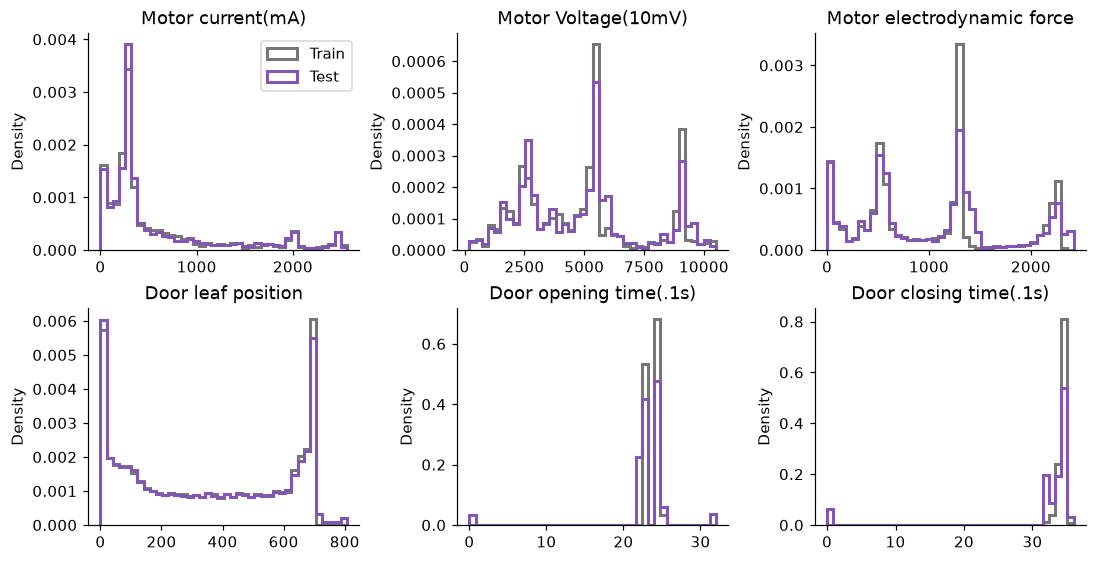

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5))
for ax, col in zip(axes.flat, CONTINUOUS):
    bins = np.histogram_bin_edges(pd.concat([train[col], test[col]]), bins=40)
    ax.hist(train[col], bins=bins, density=True, histtype="step", linewidth=2, color=viz.MUTED, label="Train")
    ax.hist(test[col], bins=bins, density=True, histtype="step", linewidth=2, color=viz.TEST_COLOR, label="Test")
    ax.set(title=col, ylabel="Density")
axes.flat[0].legend()
plt.show()

<blockquote><h3 id="5-3"><b>5.3 Discrete Columns</b></h3></blockquote>

The share of rows in which each binary column is active is compared between the streams.

In [31]:
pd.DataFrame({name: df[DISCRETE].mean() for name, df in [("train", train), ("test", test)]}).round(3)

,train,test
Close command,0.567,0.589
Open command,0.433,0.411
DCSR,0.110,0.114
DCSL,0.110,0.113
DLSR,0.067,0.072
DLSL,0.067,0.071
Door Opened,0.003,0.003
Door Locked,0.000,0.000
Door is opening,0.433,0.411
Door is closing,0.567,0.589


<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-6" style="color: black;"><b>Section 6: Label Integrity and Coverage</b></h2>
</div>

This section checks segment-label consistency, class counts, row coverage, and agreement between labelled and recorded segment lengths.

<blockquote><h3 id="6-1"><b>6.1 Answer File Consistency</b></h3></blockquote>

Segment identifiers, boundary order, overlap, and label domains are checked to establish the internal consistency of the answer file.

In [32]:
pd.Series(
    {
        "unique segment ids": answers["segment_id"].is_unique,
        "start before end": bool((answers["start"] < answers["end"]).all()),
        "ordered by start": answers["start"].is_monotonic_increasing,
        "no overlaps": bool((answers["start"].shift(-1) > answers["end"]).iloc[:-1].all()),
        "operations": value_set(answers["operation"]),
        "statuses": value_set(answers["status"]),
    }
)

unique segment ids                           True
start before end                             True
ordered by start                             True
no overlaps                                  True
operations                            Close, Open
statuses              Abnormal resistance, Normal
dtype: object

<blockquote><h3 id="6-2"><b>6.2 Label Counts</b></h3></blockquote>

A cross-tabulation counts cycles by operation and resistance status to assess class balance at the cycle level.

In [33]:
pd.crosstab(answers["operation"], answers["status"], margins=True)

status,Abnormal resistance,Normal,All
operation,,,
Close,15,40,55
Open,15,40,55
All,30,80,110


<blockquote><h3 id="6-3"><b>6.3 Row Coverage</b></h3></blockquote>

Every Train row should fall inside exactly one labelled segment.

In [34]:
containing = pd.Series(0, index=train.index)
for start, end in zip(answers["start"], answers["end"]):
    containing += train["time"].between(start, end).astype(int)
containing.value_counts().rename("rows").rename_axis("segments_containing_row")

segments_containing_row
1    18036
Name: rows, dtype: int64

<blockquote><h3 id="6-4"><b>6.4 Stated Row Counts</b></h3></blockquote>

The `n_rows` value of each answer should equal the number of Train rows inside that segment.

In [35]:
counted = [train["time"].between(start, end).sum() for start, end in zip(answers["start"], answers["end"])]
pd.Series({"n_rows equals counted rows": bool((answers["n_rows"] == counted).all())})

n_rows equals counted rows    True
dtype: bool

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-7" style="color: black;"><b>Section 7: Cycle Boundary Assessment</b></h2>
</div>

This section evaluates whether gaps in logging reproduce the labelled Train cycle boundaries and describes the resulting Test runs.

<blockquote><h3 id="7-1"><b>7.1 Gap-Delimited Runs</b></h3></blockquote>

A new run starts wherever the step between consecutive rows exceeds 20 ms.

In [36]:
train_runs = door.cycle_table(train)
test_runs = door.cycle_table(test)
pd.Series({"train runs": len(train_runs), "train segments": len(answers), "test runs": len(test_runs)})

train runs        110
train segments    110
test runs          38
dtype: int64

<blockquote><h3 id="7-2"><b>7.2 Agreement With the Answers</b></h3></blockquote>

Detected Train boundaries and row counts are compared with the answer file to measure exact segmentation agreement.

In [37]:
pd.Series(
    {
        "start matches": (train_runs["start"].values == answers["start"].values).mean(),
        "end matches": (train_runs["end"].values == answers["end"].values).mean(),
        "n_rows matches": (train_runs["n_rows"].values == answers["n_rows"].values).mean(),
    },
    name="share_of_segments",
)

start matches     1.0
end matches       1.0
n_rows matches    1.0
Name: share_of_segments, dtype: float64

<blockquote><h3 id="7-3"><b>7.3 Boundary Overlap</b></h3></blockquote>

The Door score credits each matched segment with its intersection over union (IoU). The IoU of
each run against its answer shows the boundary credit that gap-delimited runs would earn.

In [38]:
def interval_iou(a: pd.DataFrame, b: pd.DataFrame) -> pd.Series:
    """Row-wise intersection over union of the [start, end] intervals in two aligned frames."""
    inter = (np.minimum(a["end"], b["end"]) - np.maximum(a["start"], b["start"])).clip(lower=pd.Timedelta(0))
    union = (a["end"] - a["start"]) + (b["end"] - b["start"]) - inter
    return inter / union

The interval intersection-over-union values are summarised to quantify the overlap between detected Train runs and labelled segments.

In [39]:
interval_iou(train_runs, answers).describe()

count    110.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
dtype: float64

<blockquote><h3 id="7-4"><b>7.4 Run Lengths</b></h3></blockquote>

Run lengths in the Test stream are compared with the labelled Train cycles.

In [40]:
pd.DataFrame({"train": train_runs["n_rows"].describe(), "test": test_runs["n_rows"].describe()}).round(1)

,train,test
count,110.0,38.0
mean,164.0,164.6
std,22.1,22.5
min,137.0,135.0
25%,142.0,142.0
50%,162.5,174.0
75%,186.0,186.8
max,190.0,190.0


<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-8" style="color: black;"><b>Section 8: Operation Identification</b></h2>
</div>

This section examines command indicators, position changes, and cycle ordering to assess an operation-identification rule.

<blockquote><h3 id="8-1"><b>8.1 Indicator Columns</b></h3></blockquote>

The following function summarises command and state maxima and the first and last door positions within each run for operation analysis.

In [41]:
def run_summary(stream: pd.DataFrame) -> pd.DataFrame:
    """Per-run maxima of the command and state columns, plus first and last door position."""
    runs = stream.groupby(door.split_cycles(stream["time"]))
    indicators = runs[door.COMMANDS + ["Door Opened", "Door is opening", "Door is closing"]].max()
    travel = runs[door.POSITION].agg(position_start="first", position_end="last")
    return indicators.join(travel)

The run summaries are joined to the Train labels, and command combinations are counted by operation to assess their consistency with the annotations.

In [42]:
train_summary = run_summary(train).join(answers[["operation", "status"]])
pd.crosstab(train_summary["operation"], [train_summary["Open command"], train_summary["Close command"]])

Open command,0,1
Close command,1,0
operation,,
Close,55,0
Open,0,55


<blockquote><h3 id="8-2"><b>8.2 Operation Rule</b></h3></blockquote>

A run is labelled Open when its open command is ever active, and Close otherwise.

In [43]:
def operation_of(summary: pd.DataFrame) -> pd.Series:
    """Open when the run's open command is ever active, otherwise Close."""
    return summary["Open command"].map({1: "Open", 0: "Close"}).rename("operation")

The command-based operation rule is compared with all Train operation labels to measure agreement on the available labelled cycles.

In [44]:
pd.Series({"rule agrees with answers": (operation_of(train_summary) == train_summary["operation"]).mean()})

rule agrees with answers    1.0
dtype: float64

<blockquote><h3 id="8-3"><b>8.3 Position Travel</b></h3></blockquote>

Start and end position ranges are grouped by labelled operation to assess travel direction and endpoint variability.

In [45]:
train_summary.groupby("operation")[["position_start", "position_end"]].agg(["min", "max"])

position_start      position_end     
                     min  max          min  max
operation                                      
Close                700  700            0    2
Open                   0    0          695  705

<blockquote><h3 id="8-4"><b>8.4 Operation Order</b></h3></blockquote>

The alternation rate and longest sequence of one operation describe the order of recorded cycles. These statistics assess ordering but do not establish independence or a single physical door history.

In [46]:
changes = answers["operation"].ne(answers["operation"].shift())
pd.Series(
    {
        "share of consecutive pairs that alternate": round(changes.iloc[1:].mean(), 3),
        "longest run of one operation": int(changes.cumsum().value_counts().max()),
    },
    dtype=object,
)

share of consecutive pairs that alternate    0.477
longest run of one operation                     8
dtype: object

<blockquote><h3 id="8-5"><b>8.5 Cycle Length by Operation</b></h3></blockquote>

Cycle lengths are summarised by labelled operation. Consecutive readings within a cycle are separated by 20 ms, so the elapsed first-to-last duration is based on one fewer interval than the row count.

In [47]:
answers.groupby("operation")["n_rows"].describe()

,count,mean,std,min,25%,50%,75%,max
operation,,,,,,,,
Close,55.0,185.909091,2.136740,178.0,185.0,186.0,187.0,190.0
Open,55.0,142.018182,2.094887,137.0,141.0,142.0,143.0,147.0


<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-9" style="color: black;"><b>Section 9: Within-Cycle Signal Analysis</b></h2>
</div>

This section adds cycle context and compares signal traces, normalised current profiles, position-dependent current, and controller timing updates.

<blockquote><h3 id="9-1"><b>9.1 Row Context</b></h3></blockquote>

Each Train row receives its cycle number, the time elapsed since the cycle started, and the
cycle's operation and status.

In [48]:
train["cycle"] = door.split_cycles(train["time"])
train["t_s"] = (train["time"] - train.groupby("cycle")["time"].transform("first")).dt.total_seconds()
train = train.join(answers[["operation", "status"]], on="cycle")

<blockquote><h3 id="9-2"><b>9.2 Example Cycles</b></h3></blockquote>

The first Normal and the first Abnormal resistance cycle of each operation are overlaid on a time
axis measured from cycle start.

In [49]:
examples = answers.groupby(["operation", "status"]).head(1)
examples[["segment_id", "operation", "status", "n_rows"]]

,segment_id,operation,status,n_rows
cycle,,,,
0,train_seg_001,Close,Normal,186
1,train_seg_002,Open,Normal,143
2,train_seg_003,Open,Abnormal resistance,137
3,train_seg_004,Close,Abnormal resistance,187


The selected example cycles are plotted against elapsed time to compare current, voltage, back-EMF, and position within each operation.

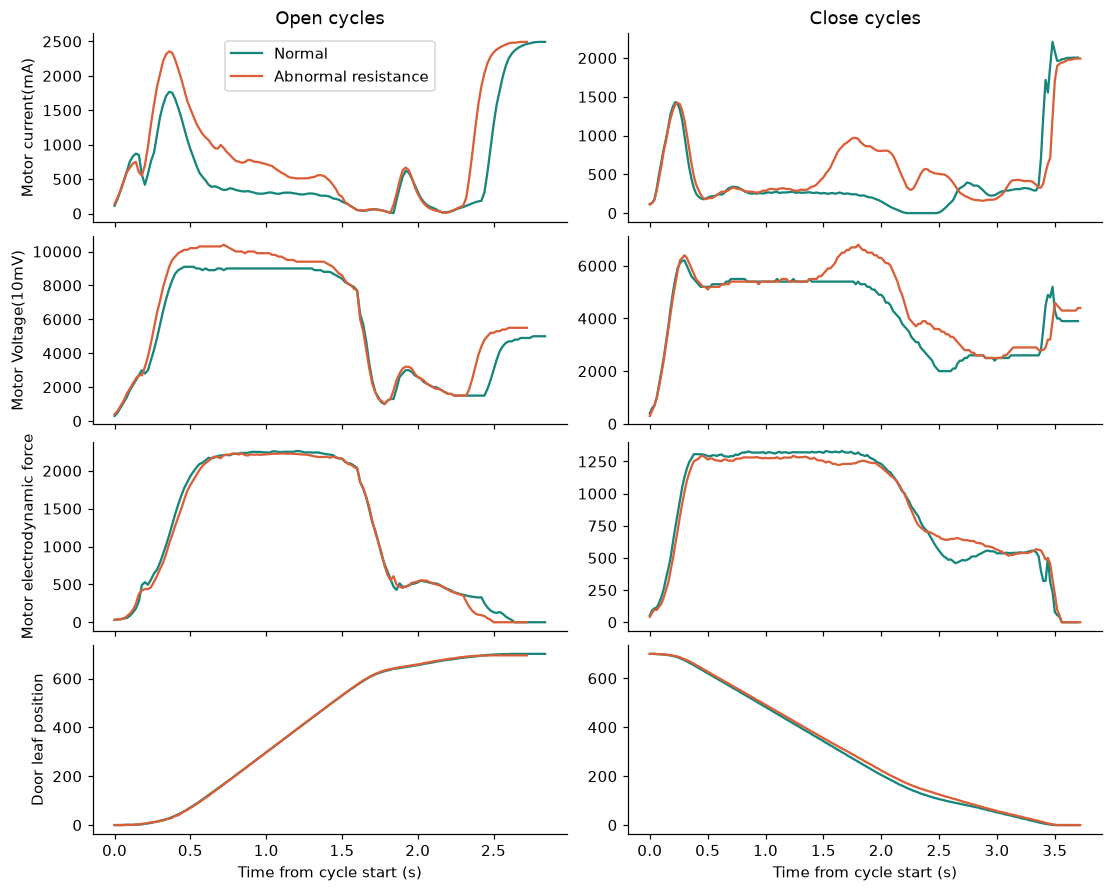

In [50]:
SIGNALS = [door.CURRENT, door.VOLTAGE, door.BACK_EMF, door.POSITION]
fig, axes = plt.subplots(len(SIGNALS), 2, figsize=(10, 8), sharex="col")
for col, op in enumerate(["Open", "Close"]):
    for cycle, row in examples[examples["operation"] == op].iterrows():
        rows = train[train["cycle"] == cycle]
        for ax, signal in zip(axes[:, col], SIGNALS):
            ax.plot(rows["t_s"], rows[signal], color=viz.CLASS_COLORS[row["status"]], label=row["status"])
    axes[0, col].set_title(f"{op} cycles")
    axes[-1, col].set_xlabel("Time from cycle start (s)")
for ax, signal in zip(axes[:, 0], SIGNALS):
    ax.set_ylabel(signal)
axes[0, 0].legend()
plt.show()

<blockquote><h3 id="9-3"><b>9.3 Median Current Profiles</b></h3></blockquote>

Each cycle's current trace is resampled to 100 points across its duration. The median and
interquartile band of each class show where in the stroke the classes diverge.

In [51]:
def resample_trace(values: np.ndarray, n: int = 100) -> np.ndarray:
    """Linearly resample a trace to n points spanning its full length."""
    return np.interp(np.linspace(0, 1, n), np.linspace(0, 1, len(values)), values)

Each Train current trace is resampled and joined to its operation and status, producing aligned profiles for class comparisons.

In [52]:
traces = train.groupby("cycle")[door.CURRENT].apply(lambda s: resample_trace(s.to_numpy()))
profiles = pd.DataFrame(traces.tolist(), index=traces.index).join(answers[["operation", "status"]])

Class median profiles and interquartile bands are plotted over normalised cycle progress to compare profile shapes and within-class spread.

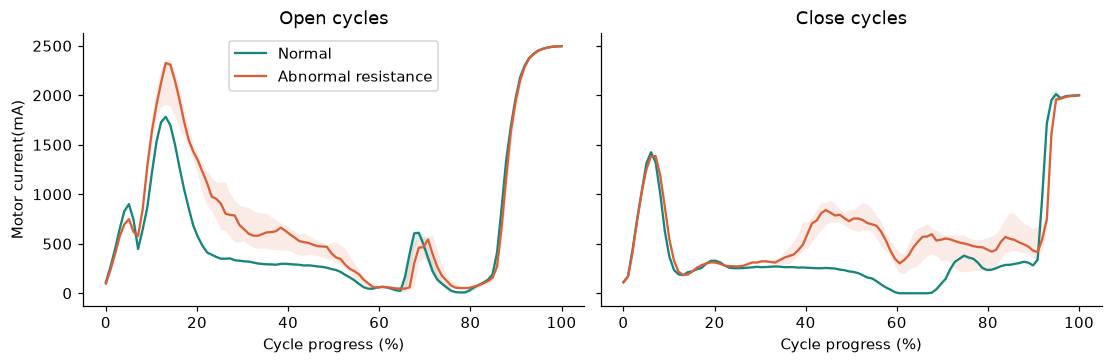

In [53]:
progress = np.linspace(0, 100, 100)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, op in zip(axes, ["Open", "Close"]):
    for status, color in viz.CLASS_COLORS.items():
        block = profiles.query("operation == @op and status == @status").drop(columns=["operation", "status"])
        q = block.quantile([0.25, 0.5, 0.75])
        ax.fill_between(progress, q.loc[0.25], q.loc[0.75], color=color, alpha=0.12, linewidth=0)
        ax.plot(progress, q.loc[0.5], color=color, label=status)
    ax.set(title=f"{op} cycles", xlabel="Cycle progress (%)")
axes[0].set_ylabel(door.CURRENT)
axes[0].legend()
plt.show()

<blockquote><h3 id="9-4"><b>9.4 Current Against Door Position</b></h3></blockquote>

Median current is computed in 25-unit door position bins to locate where along the stroke the extra
resistance appears.

In [54]:
train["position_bin"] = (train[door.POSITION] // 25) * 25
by_position = (
    train.groupby(["operation", "status", "position_bin"])[door.CURRENT].median().rename("current").reset_index()
)

Position-binned current medians are plotted separately for Open and Close cycles to compare class differences along the stroke.

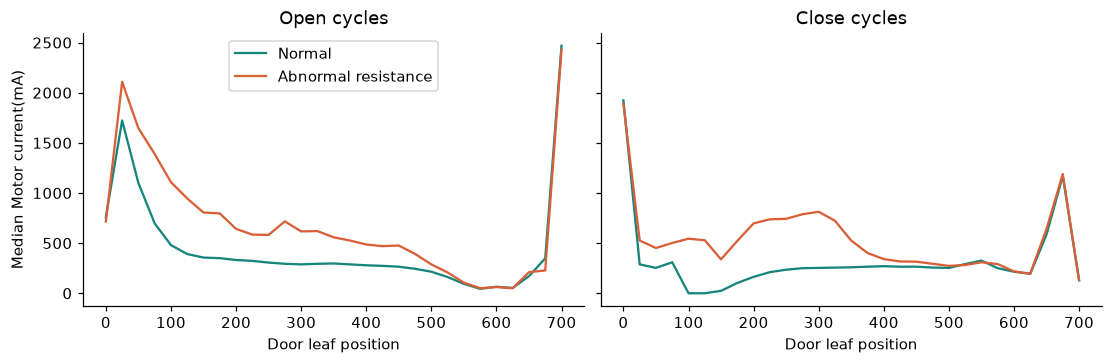

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, op in zip(axes, ["Open", "Close"]):
    for status, color in viz.CLASS_COLORS.items():
        line = by_position.query("operation == @op and status == @status")
        ax.plot(line["position_bin"], line["current"], color=color, label=status)
    ax.set(title=f"{op} cycles", xlabel="Door leaf position")
axes[0].set_ylabel(f"Median {door.CURRENT}")
axes[0].legend()
plt.show()

<blockquote><h3 id="9-5"><b>9.5 Timing Column Updates</b></h3></blockquote>

The opening and closing time columns change value inside some cycles. The elapsed time at each
change, grouped by the cycle's operation, shows when the controller refreshes these values.

In [56]:
def timing_updates(stream: pd.DataFrame, column: str) -> pd.DataFrame:
    """Rows where a timing column changes within a run, with elapsed seconds and the run's operation."""
    cycle = door.split_cycles(stream["time"])
    changed = stream.groupby(cycle)[column].diff().fillna(0).ne(0)
    elapsed = (stream["time"] - stream.groupby(cycle)["time"].transform("first")).dt.total_seconds()
    operation = stream["Open command"].groupby(cycle).transform("max").map({1: "Open", 0: "Close"})
    return pd.DataFrame({"elapsed_s": elapsed[changed], "operation": operation[changed]})

Elapsed times of controller timing changes are summarised by operation to examine when timing values update within a cycle.

In [57]:
pd.concat(
    {column: timing_updates(train, column).groupby("operation")["elapsed_s"].describe() for column in door.TIMING}
).round(2)

,,count,mean,std,min,25%,50%,75%,max
,operation,,,,,,,,
Door opening time(.1s),Open,30.0,2.59,0.04,2.50,2.56,2.60,2.62,2.7
Door closing time(.1s),Close,18.0,3.47,0.04,3.34,3.46,3.48,3.50,3.5


<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-10" style="color: black;"><b>Section 10: Normal and Abnormal Resistance Comparison</b></h2>
</div>

This section constructs cycle summaries and describes class differences within each operation. Separability statistics are exploratory training results, not validation scores.

<blockquote><h3 id="10-1"><b>10.1 Cycle Features</b></h3></blockquote>

Each cycle is reduced to its length, summary statistics of the motor signals, and the controller
timing values recorded at its last row.

In [58]:
def cycle_features(stream: pd.DataFrame) -> pd.DataFrame:
    """Per-run length, motor current, voltage and back-EMF statistics, and final timing values."""
    runs = stream.groupby(door.split_cycles(stream["time"]))
    return pd.DataFrame(
        {
            "n_rows": runs.size(),
            "current_mean": runs[door.CURRENT].mean(),
            "current_max": runs[door.CURRENT].max(),
            "voltage_mean": runs[door.VOLTAGE].mean(),
            "voltage_max": runs[door.VOLTAGE].max(),
            "emf_mean": runs[door.BACK_EMF].mean(),
            "emf_max": runs[door.BACK_EMF].max(),
            "open_time": runs[door.OPEN_TIME].last(),
            "close_time": runs[door.CLOSE_TIME].last(),
        }
    )

Cycle summaries are joined to the Train labels, and numerical feature columns are selected for descriptive class comparisons.

In [59]:
features = cycle_features(train).join(answers[["operation", "status"]])
FEATURES = [c for c in features.columns if c not in ("operation", "status")]
features.head()

,n_rows,current_mean,current_max,voltage_mean,voltage_max,emf_mean,emf_max,open_time,close_time,operation,status
cycle,,,,,,,,,,,
0,186,430.698925,2208,4146.236559,6200,892.069892,1331,24,35,Close,Normal
1,143,636.265734,2493,5521.678322,9100,1178.727273,2261,24,35,Open,Normal
2,137,862.452555,2493,6197.080292,10400,1192.430657,2230,23,35,Open,Abnormal resistance
3,187,576.577540,1993,4524.598930,6800,878.304813,1294,24,35,Close,Abnormal resistance
4,186,484.548387,1993,4339.247312,6400,881.526882,1298,23,35,Close,Abnormal resistance


<blockquote><h3 id="10-2"><b>10.2 Class Means</b></h3></blockquote>

Feature means are grouped by operation and status to compare class averages without mixing opening and closing regimes.

In [60]:
features.groupby(["operation", "status"])[FEATURES].mean().T.round(1)

operation                  Close                        Open        
status       Abnormal resistance  Normal Abnormal resistance  Normal
n_rows                     187.0   185.5               142.1   142.0
current_mean               615.0   428.1               824.7   646.9
current_max               2006.3  2147.8              2503.9  2501.2
voltage_mean              4603.1  4143.0              5960.1  5562.4
voltage_max               6686.7  6217.5             10320.0  9177.5
emf_mean                   879.4   893.4              1165.3  1185.9
emf_max                   1297.6  1331.0              2232.8  2272.8
open_time                   23.5    23.6                23.7    23.6
close_time                  34.8    34.7                34.8    34.7

<blockquote><h3 id="10-3"><b>10.3 Single-Feature Separability</b></h3></blockquote>

Direction-free single-feature ROC AUC describes separation on these same training cycles. Taking max(AUC, 1-AUC) chooses the direction retrospectively and is optimistic. These are exploratory statistics, not validation or the official IoU-weighted F1.

In [61]:
def separability(frame: pd.DataFrame, columns: list[str]) -> pd.Series:
    """Direction-free ROC AUC of each column for Abnormal resistance against Normal."""
    abnormal = frame["status"].eq("Abnormal resistance")
    auc = {c: roc_auc_score(abnormal, frame[c]) for c in columns if frame[c].nunique() > 1}
    return pd.Series(auc).map(lambda v: max(v, 1 - v))

Direction-free feature AUC values are calculated separately for each operation to describe separation within the labelled Train data.

In [62]:
pd.DataFrame({op: separability(features[features["operation"] == op], FEATURES) for op in ["Open", "Close"]}).round(2)

,Open,Close
n_rows,0.52,0.82
current_mean,1.00,1.00
current_max,0.51,1.00
voltage_mean,1.00,1.00
voltage_max,1.00,0.98
emf_mean,0.78,0.90
emf_max,0.78,1.00
open_time,0.54,0.57
close_time,0.54,0.54


<blockquote><h3 id="10-4"><b>10.4 Mean Current by Class</b></h3></blockquote>

Mean current per cycle is plotted for each class and operation.

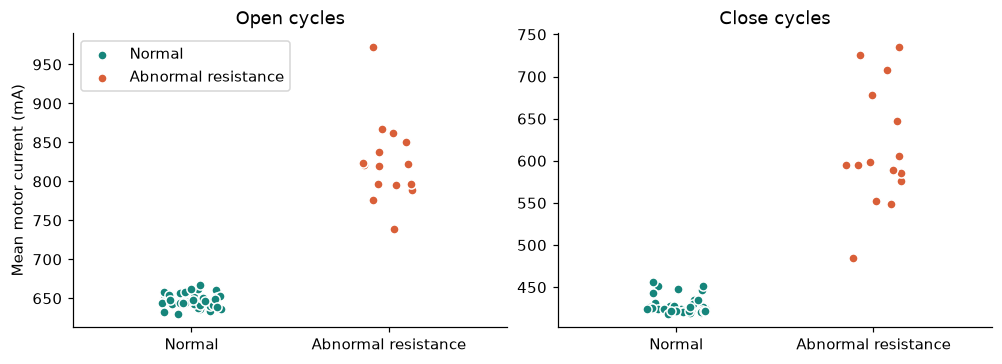

In [63]:
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for ax, op in zip(axes, ["Open", "Close"]):
    for i, (status, color) in enumerate(viz.CLASS_COLORS.items()):
        values = features.query("operation == @op and status == @status")["current_mean"]
        jitter = i + rng.uniform(-0.15, 0.15, len(values))
        ax.scatter(jitter, values, s=36, color=color, edgecolor=viz.SURFACE, linewidth=1, label=status)
    ax.set(title=f"{op} cycles", xticks=[0, 1], xticklabels=list(viz.CLASS_COLORS), xlim=(-0.6, 1.6))
axes[0].set_ylabel("Mean motor current (mA)")
axes[0].legend()
plt.show()

<blockquote><h3 id="10-5"><b>10.5 Class Margin</b></h3></blockquote>

The gap between the highest Normal and the lowest Abnormal resistance mean current shows how much
room a single threshold has in the training data.

In [64]:
ranges = features.groupby(["operation", "status"])["current_mean"].agg(["min", "max"]).unstack("status")
margins = pd.DataFrame(
    {
        "normal_max": ranges[("max", "Normal")],
        "abnormal_min": ranges[("min", "Abnormal resistance")],
    }
).assign(margin=lambda d: d["abnormal_min"] - d["normal_max"])
margins.round(1)

,normal_max,abnormal_min,margin
operation,,,
Close,456.2,484.5,28.3
Open,666.5,738.3,71.8


<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-11" style="color: black;"><b>Section 11: Train and Test Distribution Comparison</b></h2>
</div>

This section compares unlabelled Test cycles with Train distributions, reference ranges, and profiles. The comparisons do not establish Test fault labels.

<blockquote><h3 id="11-1"><b>11.1 Test Cycle Features</b></h3></blockquote>

Test runs receive the same features, with the operation taken from the rule in Section 8.2.

In [65]:
test_summary = run_summary(test)
test_features = cycle_features(test).join(operation_of(test_summary))
test_features["operation"].value_counts()

operation
Close    20
Open     18
Name: count, dtype: int64

<blockquote><h3 id="11-2"><b>11.2 Test Cycles Against Train Classes</b></h3></blockquote>

Test cycles are placed beside the labelled Train classes on the mean current scale, separately for
each operation.

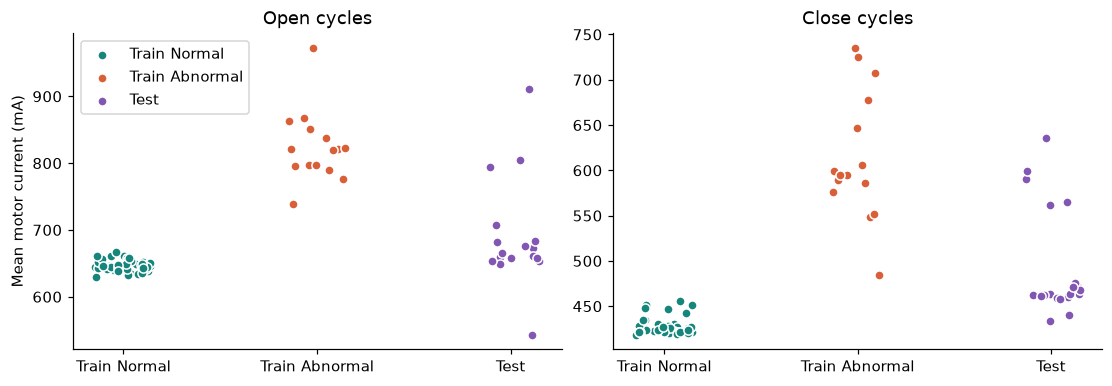

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, op in zip(axes, ["Open", "Close"]):
    groups = [
        ("Train Normal", features.query("operation == @op and status == 'Normal'"), viz.CLASS_COLORS["Normal"]),
        ("Train Abnormal", features.query("operation == @op and status != 'Normal'"), viz.CLASS_COLORS["Abnormal resistance"]),
        ("Test", test_features.query("operation == @op"), viz.TEST_COLOR),
    ]
    for i, (name, frame, color) in enumerate(groups):
        jitter = i + rng.uniform(-0.15, 0.15, len(frame))
        ax.scatter(jitter, frame["current_mean"], s=36, color=color, edgecolor=viz.SURFACE, linewidth=1, label=name)
    ax.set(title=f"{op} cycles", xticks=range(3), xticklabels=[g[0] for g in groups])
axes[0].set_ylabel("Mean motor current (mA)")
axes[0].legend()
plt.show()

<blockquote><h3 id="11-3"><b>11.3 Position Against the Train Margins</b></h3></blockquote>

Each Test cycle is placed relative to the Train margin for its operation: at or below the highest
Normal value, at or above the lowest Abnormal resistance value, or between the two.

In [67]:
def margin_zone(row: pd.Series) -> str:
    """Locate a cycle's mean current relative to the Train Normal maximum and Abnormal minimum."""
    bounds = margins.loc[row["operation"]]
    if row["current_mean"] <= bounds["normal_max"]:
        return "at or below Normal max"
    if row["current_mean"] >= bounds["abnormal_min"]:
        return "at or above Abnormal min"
    return "between"

Test cycles are counted by operation and Train reference zone to describe their positions relative to the observed class ranges.

In [68]:
pd.crosstab(test_features["operation"], test_features.apply(margin_zone, axis=1).rename("zone"))

zone,at or above Abnormal min,at or below Normal max,between
operation,,,
Close,5,2,13
Open,3,10,5


<blockquote><h3 id="11-4"><b>11.4 Zeroed Timing Values in Test</b></h3></blockquote>

Test runs in which an opening or closing time reads zero are listed with their first and last
timing values, operation, length, travel and mean current.

In [69]:
def timing_runs(stream: pd.DataFrame) -> pd.DataFrame:
    """First and last opening and closing time of each run."""
    runs = stream.groupby(door.split_cycles(stream["time"]))[door.TIMING]
    return runs.first().add_suffix(" first").join(runs.last().add_suffix(" last"))

Test runs containing at least one zero opening-time or closing-time reading are identified for targeted inspection.

In [70]:
zero_runs = test.groupby(door.split_cycles(test["time"]))[door.TIMING].min().eq(0).any(axis=1).loc[lambda s: s].index
list(zero_runs)

[24, 32]

The identified Test runs are summarised using timing endpoints, operation, length, mean current, and position endpoints to provide context for zero timing values.

In [71]:
timing_runs(test).loc[zero_runs].join(
    test_features.loc[zero_runs, ["operation", "n_rows", "current_mean"]]
).join(test_summary.loc[zero_runs, ["position_start", "position_end"]])

,Door opening time(.1s) first,Door closing time(.1s) first,Door opening time(.1s) last,Door closing time(.1s) last,operation,n_rows,current_mean,position_start,position_end
cycle,,,,,,,,,
24,32,0,32,32,Close,173,462.023121,700,0
32,0,0,32,0,Open,185,543.281081,0,807


<blockquote><h3 id="11-5"><b>11.5 Position Travel in Test</b></h3></blockquote>

Test position endpoints are summarised by operation to inspect travel ranges and support comparison with the Train ranges.

In [72]:
test_summary.join(operation_of(test_summary)).groupby("operation")[["position_start", "position_end"]].agg(["min", "max"])

position_start      position_end     
                     min  max          min  max
operation                                      
Close                700  700            0    3
Open                   0    0          693  807

<blockquote><h3 id="11-6"><b>11.6 Profiles of Between-Range Test Cycles</b></h3></blockquote>

Between-range Test profiles are aligned with Train class profiles to examine differences in shape. Similarity is descriptive because the Test stream has no resistance labels.

In [73]:
test_traces = test.groupby(door.split_cycles(test["time"]))[door.CURRENT].apply(lambda s: resample_trace(s.to_numpy()))
test_profiles = pd.DataFrame(test_traces.tolist(), index=test_traces.index).join(
    test_features[["operation"]].assign(zone=test_features.apply(margin_zone, axis=1))
)

Between-range Test median profiles are plotted with the Train class medians to compare current patterns over cycle progress without assigning Test labels.

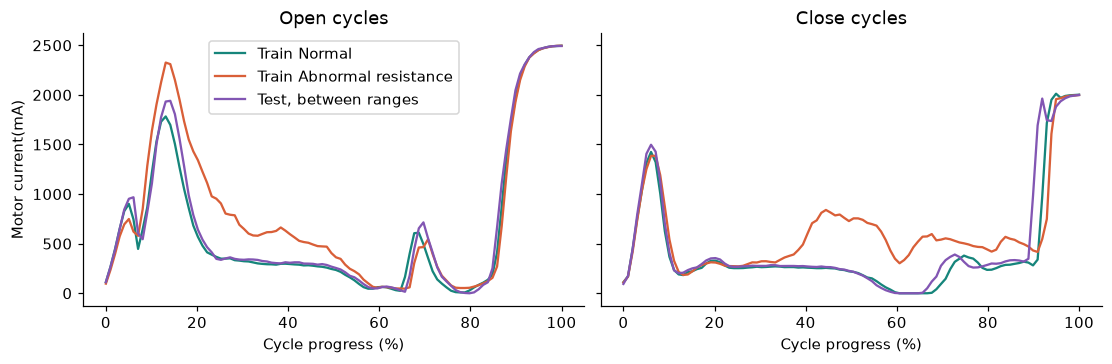

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, op in zip(axes, ["Open", "Close"]):
    for status, color in viz.CLASS_COLORS.items():
        block = profiles.query("operation == @op and status == @status").drop(columns=["operation", "status"])
        ax.plot(progress, block.median(), color=color, label=f"Train {status}")
    between = test_profiles.query("operation == @op and zone == 'between'").drop(columns=["operation", "zone"])
    ax.plot(progress, between.median(), color=viz.TEST_COLOR, label="Test, between ranges")
    ax.set(title=f"{op} cycles", xlabel="Cycle progress (%)")
axes[0].set_ylabel(door.CURRENT)
axes[0].legend()
plt.show()

<blockquote><h3 id="11-7"><b>11.7 Current by Cycle Phase</b></h3></blockquote>

Mean current is compared over three selected progress ranges: 0–30%, 35–65%, and 85–100%. These ranges separate early, middle, and late portions of the recorded stroke for descriptive comparison.

In [75]:
PHASES = {
    "start_0_30": list(range(0, 30)),
    "middle_35_65": list(range(35, 65)),
    "end_85_100": list(range(85, 100)),
}


def phase_means(frame: pd.DataFrame, keys: list[str]) -> pd.DataFrame:
    """Mean current in each cycle phase, averaged over the cycles of each group."""
    return pd.DataFrame({name: frame.groupby(keys)[cols].mean().mean(axis=1) for name, cols in PHASES.items()})

Phase-level mean currents are compared across Train classes and Test reference zones to localise descriptive differences within the stroke.

In [76]:
pd.concat(
    {
        "train": phase_means(profiles, ["operation", "status"]),
        "test": phase_means(test_profiles, ["operation", "zone"]),
    }
).round(0)

start_0_30  middle_35_65  end_85_100
      operation                                                               
train Close     Abnormal resistance            479.0         608.0      1198.0
                Normal                         450.0         167.0      1257.0
      Open      Abnormal resistance           1152.0         368.0      1986.0
                Normal                         773.0         191.0      2036.0
test  Close     at or above Abnormal min       510.0         564.0      1209.0
                at or below Normal max         457.0         176.0      1259.0
                between                        481.0         169.0      1372.0
      Open      at or above Abnormal min      1193.0         327.0      1981.0
                at or below Normal max         791.0         190.0      1985.0
                between                        843.0         206.0      2086.0

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-12" style="color: black;"><b>Section 12: Extended Cycle-Level Analysis</b></h2>
</div>

This section examines boundary sensitivity, motion and electrical-load summaries, contextual outliers, repeated traces, recording order, and uncertainty. The observational unit is a cycle; independence between cycles remains unverified. Cycle numbers are zero-based, and `segment_id` is a separate answer-file identifier.

<blockquote><h3 id="12-1"><b>12.1 Boundary Sensitivity and Label Alignment</b></h3></blockquote>

The following audit asserts Train boundary and label alignment and compares several logging-gap thresholds. This assesses sensitivity on the supplied recording; a rule that splits at any interval above 20 ms may over-segment future streams with dropped samples.

In [77]:
assert train_runs[['start','end','n_rows']].equals(answers[['start','end','n_rows']])
assert containing.eq(1).all()
assert train['status'].notna().all()
sensitivity = []
for threshold in [0.019, 0.020, 0.040, 0.1, 0.5, 1, 5, 10, 30, 60]:
    record = {'gap_threshold_s': threshold}
    for name, stream in [('Train', train), ('Test', test)]:
        ids = stream.time.diff().dt.total_seconds().gt(threshold).cumsum()
        bounds = stream.groupby(ids).time.agg(['first','last'])
        record[name+'_cycles'] = len(bounds)
        if name == 'Train':
            expected = set(zip(answers.start, answers.end))
            record['exact_train_intervals'] = sum((a,b) in expected for a,b in zip(bounds['first'],bounds['last']))
    sensitivity.append(record)
display(pd.DataFrame(sensitivity))


,gap_threshold_s,Train_cycles,exact_train_intervals,Test_cycles
0,0.019,18036,0,6253
1,0.020,110,110,38
2,0.040,110,110,38
3,0.100,110,110,38
4,0.500,110,110,38
5,1.000,110,110,38
6,5.000,110,110,38
7,10.000,110,110,38
8,30.000,66,39,25
9,60.000,1,0,1


<blockquote><h3 id="12-2"><b>12.2 Motion, Electrical Load, and Controller Consistency</b></h3></blockquote>

The following cell calculates cycle-level duration, current, motion, and controller-consistency summaries. Position speed is expressed in position units per second because physical position units are undocumented. Current multiplied by voltage provides an electrical-power proxy using the recorded scaling; its within-cycle integral is not calibrated mechanical work. Stationary samples, reversals, and switch disagreements require contextual interpretation.

In [78]:
def extended_features(stream):
    rows = []
    for cycle, g in stream.groupby(door.split_cycles(stream.time)):
        t = (g.time-g.time.iloc[0]).dt.total_seconds().to_numpy()
        current = g[door.CURRENT].to_numpy(dtype=float)
        pos = g[door.POSITION].to_numpy(dtype=float)
        delta = np.diff(pos)
        dt = np.diff(t)
        speed = np.divide(delta, dt, out=np.full(len(dt), np.nan), where=dt>0)
        direction = np.sign(pos[-1]-pos[0])
        phase = t/t[-1] if t[-1]>0 else np.zeros(len(t))
        middle = (phase>=.35)&(phase<=.65)
        rows.append(dict(cycle=cycle, duration_s=t[-1], travel=pos[-1]-pos[0],
            position_max=pos.max(), current_rms=np.sqrt(np.mean(current**2)),
            current_p95=np.quantile(current,.95), middle_current=current[middle].mean(),
            current_integral_mA_s=np.trapezoid(current,t),
            electrical_energy_proxy_J=np.trapezoid(current*g[door.VOLTAGE].to_numpy()*1e-5,t),
            abs_speed_p95=np.nanquantile(abs(speed),.95),
            stationary_fraction=np.mean(delta==0), reversal_fraction=np.mean(delta*direction<0) if direction else np.nan,
            close_switch_disagreement=(g.DCSR!=g.DCSL).mean(),
            lock_switch_disagreement=(g.DLSR!=g.DLSL).mean(),
            simultaneous_commands=((g['Open command']==1)&(g['Close command']==1)).mean(),
            simultaneous_motion_flags=((g['Door is opening']==1)&(g['Door is closing']==1)).mean()))
    return pd.DataFrame(rows).set_index('cycle')

extended = extended_features(train).join(answers[['operation','status']])
extended_test = extended_features(test).join(test_features[['operation']])
EDA_FEATURES = ['duration_s','current_rms','current_p95','middle_current',
                'current_integral_mA_s','electrical_energy_proxy_J','abs_speed_p95','stationary_fraction','reversal_fraction']
display(extended.groupby(['operation','status'])[EDA_FEATURES].agg(['median','min','max']).round(3))
checks = ['close_switch_disagreement','lock_switch_disagreement','simultaneous_commands','simultaneous_motion_flags']
display(pd.concat({name:frame[checks].gt(0).sum() for name,frame in [('Train',extended),('Test',extended_test)]},axis=1).rename_axis('check: number of affected cycles'))


duration_s             current_rms                     current_p95                  middle_current                    \
                                  median   min   max      median       min       max      median      min     max         median      min      max   
operation status                                                                                                                                     
Close     Abnormal resistance       3.72  3.70  3.78     742.420   658.660   851.835    1958.000  1873.50  2005.0        620.745  320.911  855.268   
          Normal                    3.70  3.54  3.78     667.773   659.387   712.102    1977.775  1917.60  1993.0        167.233  156.947  176.891   
Open      Abnormal resistance       2.82  2.72  2.92    1113.919  1068.694  1234.199    2456.000  2429.95  2499.5        354.619  207.833  650.357   
          Normal                    2.82  2.76  2.88     978.627   960.035  1000.271    2454.750  2431.00  2474.7        189.054  183.186  199.167   

                              current_integral_mA_s                   electrical_energy_proxy_J                   abs_speed_p95                \
                                             median      min      max                    median      min      max        median    min    max   
operation status                                                                                                                                
Close     Abnormal resistance              2207.560  1781.47  2729.31                   104.412   79.632  135.506         300.0  300.0  300.0   
          Normal                           1548.695  1529.41  1712.45                    67.048   66.245   72.300         300.0  300.0  300.0   
Open      Abnormal resistance              2324.830  2100.78  2775.66                   157.014  135.464  210.524         500.0  450.0  500.0   
          Normal                           1814.815  1772.71  1854.48                   103.303  101.323  106.514         500.0  500.0  500.0   

                              stationary_fraction               reversal_fraction            
                                           median    min    max            median  min  max  
operation status                                                                             
Close     Abnormal resistance               0.075  0.070  0.090               0.0  0.0  0.0  
          Normal                            0.071  0.060  0.090               0.0  0.0  0.0  
Open      Abnormal resistance               0.147  0.134  0.162               0.0  0.0  0.0  
          Normal                            0.148  0.133  0.163               0.0  0.0  0.0

,Train,Test
check: number of affected cycles,,
close_switch_disagreement,19,6
lock_switch_disagreement,12,12
simultaneous_commands,0,0
simultaneous_motion_flags,0,0


<blockquote><h3 id="12-3"><b>12.3 Cycle Distributions and Feature Redundancy</b></h3></blockquote>

Cycle-level box plots and individual observations compare feature distributions by operation and status. Separate Spearman correlation matrices for Open and Close cycles describe feature redundancy without implying causation.

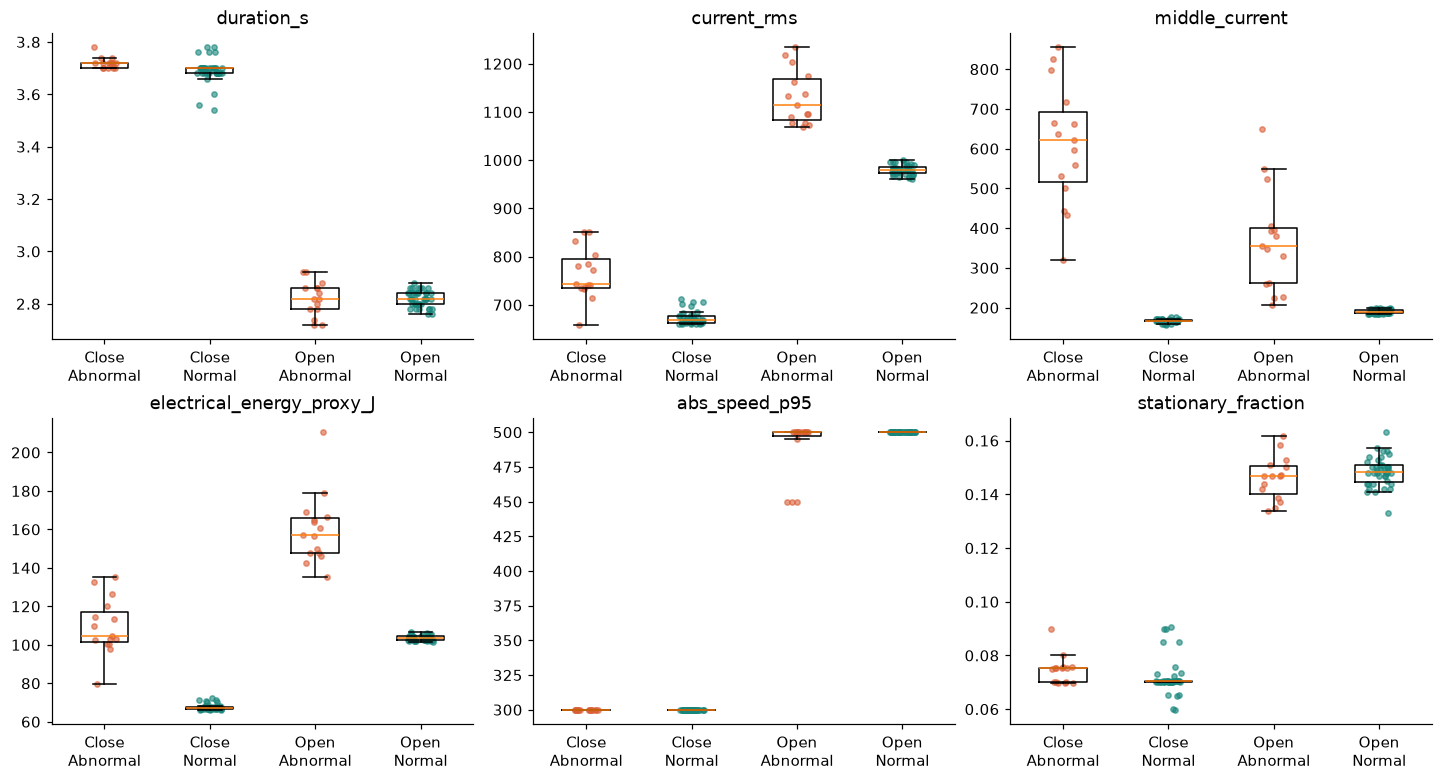

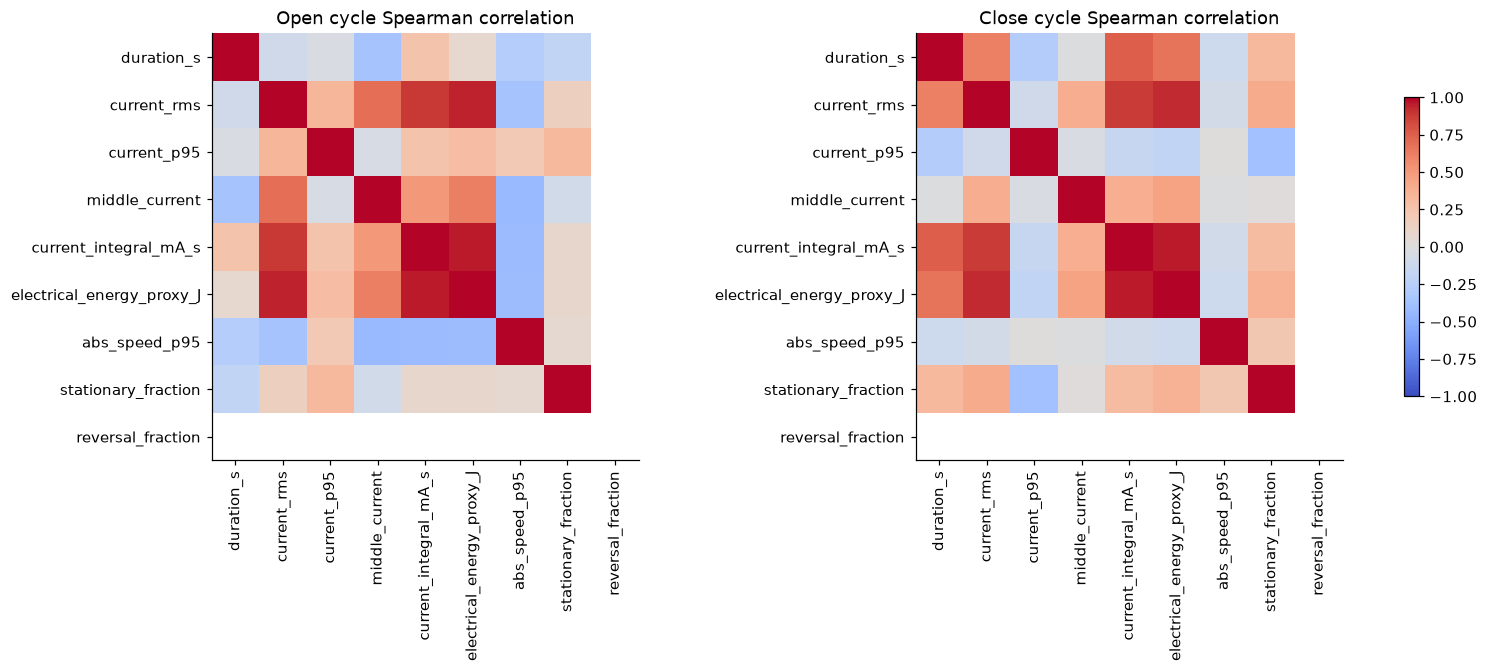

In [79]:
fig, axes = plt.subplots(2,3,figsize=(13,7))
rng_eda = np.random.default_rng(42)
for ax, feature in zip(axes.flat, ['duration_s','current_rms','middle_current','electrical_energy_proxy_J','abs_speed_p95','stationary_fraction']):
    groups = list(extended.groupby(['operation','status'],sort=True))
    ax.boxplot([g[feature].dropna() for _,g in groups],showfliers=False)
    for i, ((op,status),g) in enumerate(groups,1):
        ax.scatter(i+rng_eda.uniform(-.12,.12,len(g)),g[feature],s=12,alpha=.6,color=viz.CLASS_COLORS[status])
    ax.set(title=feature,xticks=range(1,5),xticklabels=[op+'\n'+status.replace(' resistance','') for (op,status),_ in groups])
plt.show()
fig, axes = plt.subplots(1,2,figsize=(14,6))
for ax,op in zip(axes,['Open','Close']):
    corr = extended.loc[extended.operation.eq(op),EDA_FEATURES].corr(method='spearman')
    im = ax.imshow(corr,vmin=-1,vmax=1,cmap='coolwarm')
    ax.set(title=op+' cycle Spearman correlation',xticks=range(len(corr)),yticks=range(len(corr)),
           xticklabels=corr.columns,yticklabels=corr.columns)
    ax.tick_params(axis='x',labelrotation=90)
fig.colorbar(im,ax=axes,shrink=.7)
plt.show()


<blockquote><h3 id="12-4"><b>12.4 Contextual Outlier Screening</b></h3></blockquote>

Operation-specific Normal medians and median absolute deviations (MAD) provide reference values for a robust outlier screen. Absolute robust scores above 3.5 are flagged for review; zero-MAD features are excluded and listed. Each operation has 40 Normal reference cycles, so these ranges are exploratory rather than validated alarm thresholds. No readings are removed or modified.

In [80]:
OUTLIER_FEATURES = ['duration_s','current_rms','middle_current','abs_speed_p95','stationary_fraction','position_max']
reference = extended.query("status == 'Normal'").groupby('operation')[OUTLIER_FEATURES].median()
mad = extended.query("status == 'Normal'").groupby('operation')[OUTLIER_FEATURES].agg(lambda s:(s-s.median()).abs().median())
display(mad.eq(0).rename_axis('zero MAD: excluded from robust score'))
def robust_scores(frame):
    score = pd.DataFrame(index=frame.index,columns=OUTLIER_FEATURES,dtype=float)
    for op, g in frame.groupby('operation'):
        score.loc[g.index] = .67448975*(g[OUTLIER_FEATURES]-reference.loc[op])/mad.loc[op].replace(0,np.nan)
    return score
train_robust, test_robust = robust_scores(extended), robust_scores(extended_test)
audit_tables = []
for name, frame, scores in [('Train',extended,train_robust),('Test',extended_test,test_robust)]:
    table = frame[['operation']].copy()
    table['status'] = frame['status'] if 'status' in frame else 'Unlabelled'
    table['dataset'] = name
    table['flagged_features'] = scores.abs().gt(3.5).apply(lambda r:', '.join(r.index[r]),axis=1)
    table['flag_count'] = scores.abs().gt(3.5).sum(axis=1)
    table['max_abs_robust_z'] = scores.abs().max(axis=1)
    audit_tables.append(table.reset_index())
outlier_audit = pd.concat(audit_tables,ignore_index=True)
display(outlier_audit.groupby(['dataset','operation','status']).agg(cycles=('cycle','size'),flagged_cycles=('flag_count',lambda s:s.gt(0).sum())))
display(outlier_audit.sort_values(['flag_count','max_abs_robust_z'],ascending=False).head(20))


,duration_s,current_rms,middle_current,abs_speed_p95,stationary_fraction,position_max
zero MAD: excluded from robust score,,,,,,
Close,False,False,False,True,False,True
Open,False,False,False,True,False,False


cycles  flagged_cycles
dataset operation status                                     
Test    Close     Unlabelled               20              20
        Open      Unlabelled               18              10
Train   Close     Abnormal resistance      15              15
                  Normal                   40              13
        Open      Abnormal resistance      15              15
                  Normal                   40               0

,cycle,operation,status,dataset,flagged_features,flag_count,max_abs_robust_z
142,32,Open,Unlabelled,Test,"duration_s, current_rms, middle_current, stati...",5,72.170403
134,24,Close,Unlabelled,Test,"duration_s, current_rms, middle_current, stati...",4,142.191851
117,7,Close,Unlabelled,Test,"duration_s, current_rms, middle_current, stati...",4,71.455559
146,36,Close,Unlabelled,Test,"duration_s, current_rms, middle_current, stati...",4,27.471592
114,4,Close,Unlabelled,Test,"duration_s, current_rms, middle_current, stati...",4,7.770278
36,36,Close,Abnormal resistance,Train,"current_rms, middle_current, stationary_fraction",3,247.805523
74,74,Close,Abnormal resistance,Train,"current_rms, middle_current, stationary_fraction",3,237.315734
81,81,Close,Abnormal resistance,Train,"current_rms, middle_current, stationary_fraction",3,179.541500
109,109,Close,Abnormal resistance,Train,"current_rms, middle_current, stationary_fraction",3,178.498544
3,3,Close,Abnormal resistance,Train,"current_rms, middle_current, stationary_fraction",3,169.199753


<blockquote><h3 id="12-5"><b>12.5 Flagged Test Trace Inspection</b></h3></blockquote>

Up to four Test cycles with the largest flagged robust scores are plotted against the corresponding Train Normal median and pointwise interquartile range. Phase alignment supports shape comparison, while plot titles retain actual durations. The bands are not confidence intervals, and Test resistance status remains unknown.

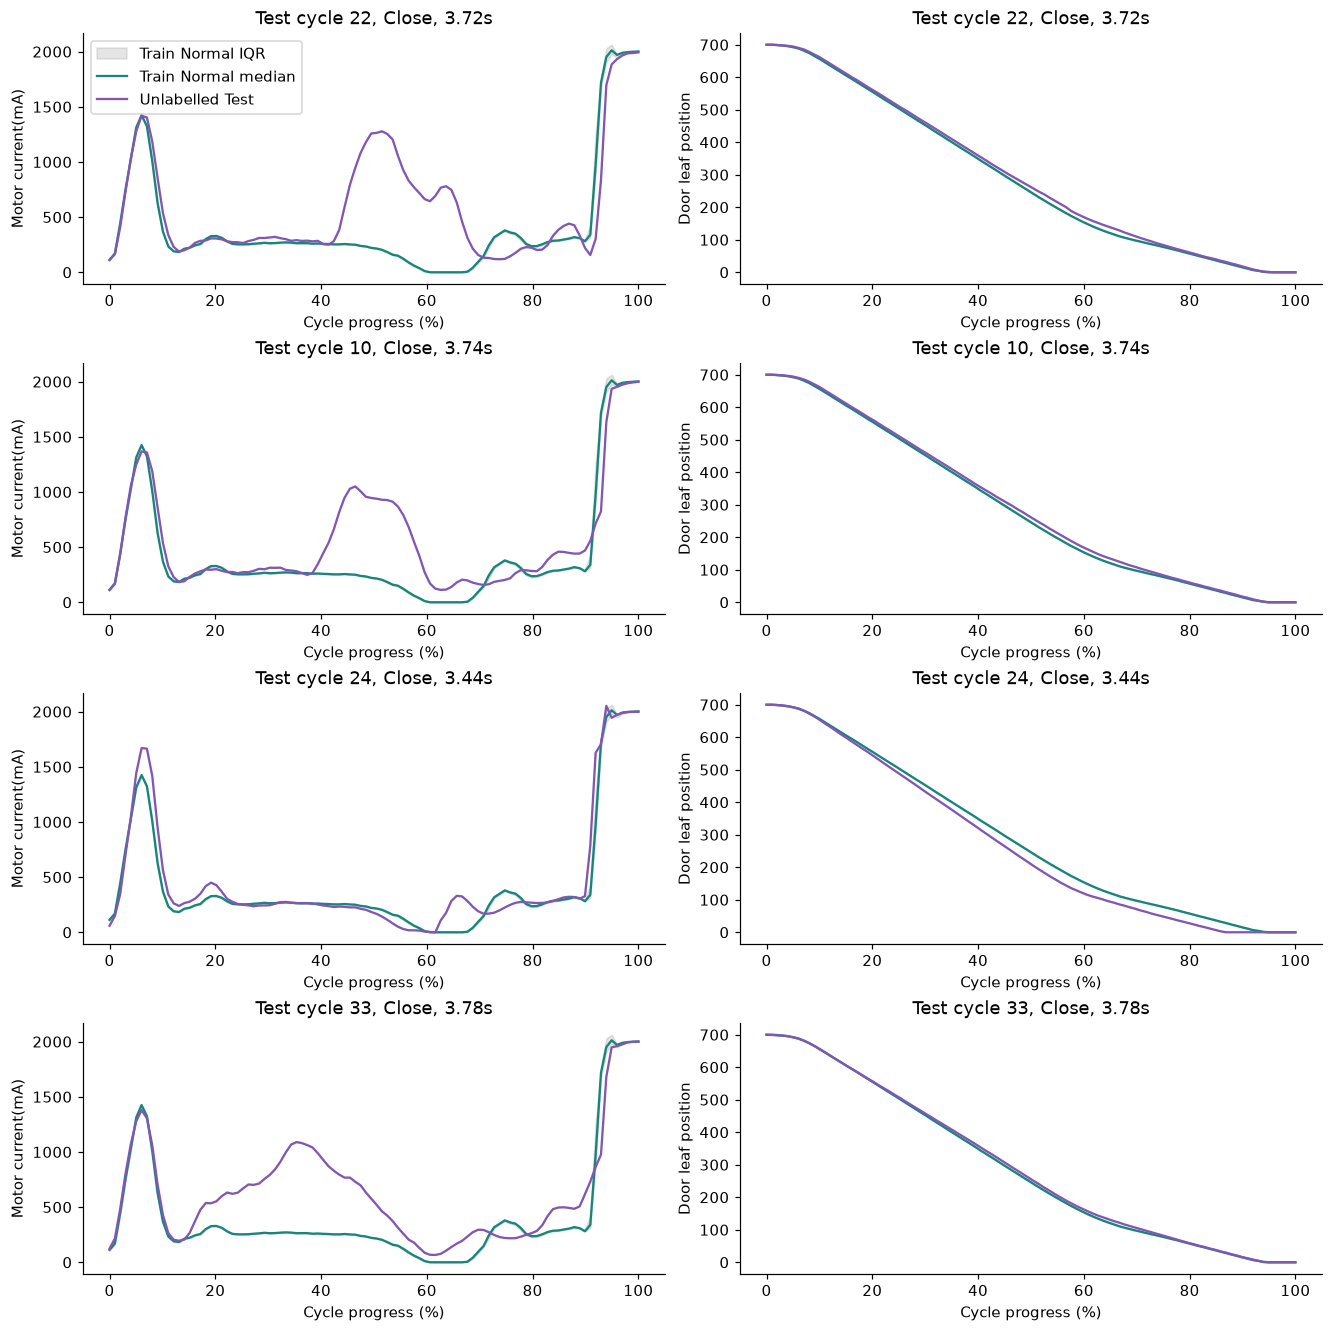

In [81]:
review_ids = outlier_audit.query("dataset == 'Test' and flag_count > 0").sort_values('max_abs_robust_z',ascending=False).head(4).cycle.tolist()
if review_ids:
    fig, axes = plt.subplots(len(review_ids),2,figsize=(12,3*len(review_ids)),squeeze=False)
    test_ids = door.split_cycles(test.time)
    for row, cycle in enumerate(review_ids):
        op = extended_test.loc[cycle,'operation']
        g = test.loc[test_ids.eq(cycle)]
        for ax, signal in zip(axes[row],[door.CURRENT,door.POSITION]):
            normal_ids = answers.index[(answers.operation==op)&(answers.status=='Normal')]
            traces = [resample_trace(train.loc[train.cycle.eq(i),signal].to_numpy()) for i in normal_ids]
            q1, med, q3 = np.quantile(traces,[.25,.5,.75],axis=0)
            ax.fill_between(progress,q1,q3,color='grey',alpha=.2,label='Train Normal IQR')
            ax.plot(progress,med,color=viz.CLASS_COLORS['Normal'],label='Train Normal median')
            ax.plot(progress,resample_trace(g[signal].to_numpy()),color=viz.TEST_COLOR,label='Unlabelled Test')
            ax.set(title=f"Test cycle {cycle}, {op}, {extended_test.loc[cycle,'duration_s']:.2f}s",xlabel='Cycle progress (%)',ylabel=signal)
    axes[0,0].legend()
    plt.show()
else:
    print('No Test cycles flagged by this screen.')


<blockquote><h3 id="12-6"><b>12.6 Quantified Train and Test Shift</b></h3></blockquote>

Train and Test median differences are scaled by the Train interquartile range within each operation. The table also reports the proportion of Test cycles outside the Train range. Zero interquartile ranges produce undefined scaled differences. Unlabelled Test comparisons cannot establish fault rates or identify the unique cause of distribution changes.

In [82]:
shift_rows = []
for op in ['Open','Close']:
    a = extended.loc[extended.operation.eq(op),EDA_FEATURES]
    b = extended_test.loc[extended_test.operation.eq(op),EDA_FEATURES]
    iqr = (a.quantile(.75)-a.quantile(.25)).replace(0,np.nan)
    for col in EDA_FEATURES:
        shift_rows.append(dict(operation=op,feature=col,train_n=len(a),test_n=len(b),
            train_median=a[col].median(),test_median=b[col].median(),
            median_shift_train_IQR=(b[col].median()-a[col].median())/iqr[col],
            test_outside_train_range_pct=100*((b[col]<a[col].min())|(b[col]>a[col].max())).mean()))
shift_audit = pd.DataFrame(shift_rows)
display(shift_audit.round(3))


,operation,feature,train_n,test_n,train_median,test_median,median_shift_train_IQR,test_outside_train_range_pct
0,Open,duration_s,55,18,2.820,2.820,0.000,22.222
1,Open,current_rms,55,18,983.389,1003.048,0.210,11.111
2,Open,current_p95,55,18,2454.750,2452.925,-0.144,11.111
3,Open,middle_current,55,18,193.674,199.753,0.213,11.111
4,Open,current_integral_mA_s,55,18,1825.190,1859.720,0.110,0.000
5,Open,electrical_energy_proxy_J,55,18,104.202,105.952,0.048,5.556
6,Open,abs_speed_p95,55,18,500.000,500.000,NaN,5.556
7,Open,stationary_fraction,55,18,0.148,0.148,0.000,11.111
8,Open,reversal_fraction,55,18,0.000,0.000,NaN,0.000
9,Close,duration_s,55,20,3.700,3.710,0.250,25.000


<blockquote><h3 id="12-7"><b>12.7 Repeated Cycles and Recording-Order Confounding</b></h3></blockquote>

Sensor-trace fingerprints identify exact repeated cycles after excluding timestamps. Class counts and middle-phase current are also examined across recording order to assess possible confounding. Absence of exact duplicates does not exclude near duplicates or shared source doors and sessions.

extra exact repeated Train cycles               0
extra exact repeated Test cycles                0
Test cycles exactly matching any Train trace    0
dtype: int64

col_0               Close                       Open       
col_1 Abnormal resistance Normal Abnormal resistance Normal
row_0                                                      
Q1                      3      7                   5     13
Q2                      3     11                   2     11
Q3                      5      9                   4      9
Q4                      4     13                   4      7

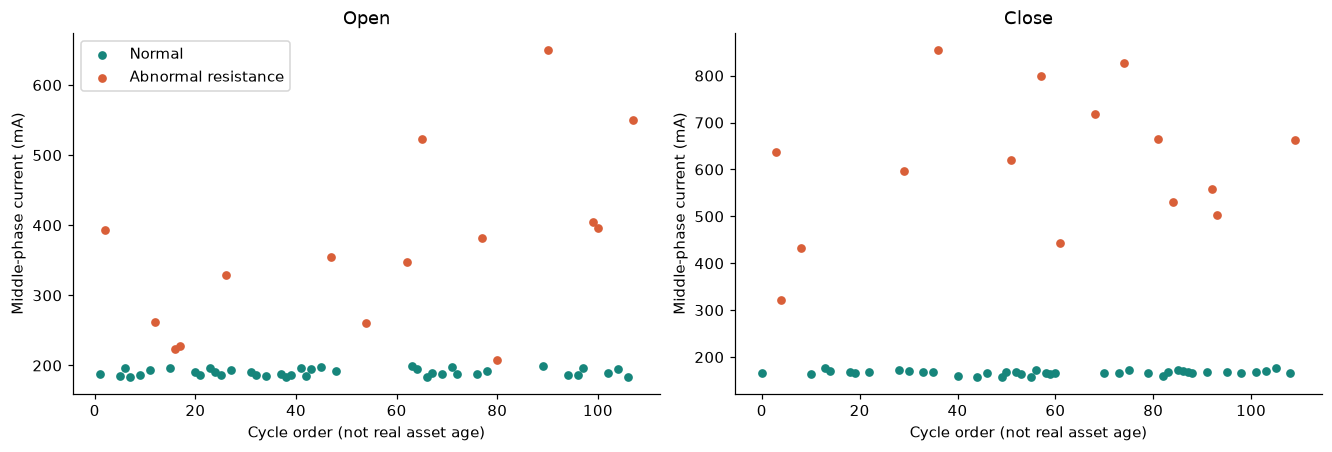

In [83]:
import hashlib
sensor_cols = door.ANALOGUE + door.TIMING + DISCRETE
def fingerprints(stream):
    return pd.Series({i:hashlib.sha256(pd.util.hash_pandas_object(g[sensor_cols].reset_index(drop=True),index=False).to_numpy().tobytes()).hexdigest()
                      for i,g in stream.groupby(door.split_cycles(stream.time))})
train_hash, test_hash = fingerprints(train), fingerprints(test)
display(pd.Series({'extra exact repeated Train cycles':train_hash.duplicated().sum(),
                   'extra exact repeated Test cycles':test_hash.duplicated().sum(),
                   'Test cycles exactly matching any Train trace':test_hash.isin(train_hash).sum()}))
order_blocks = pd.cut(np.arange(len(extended)),bins=4,labels=['Q1','Q2','Q3','Q4'])
display(pd.crosstab(order_blocks,[extended.operation.to_numpy(),extended.status.to_numpy()]))
fig, axes = plt.subplots(1,2,figsize=(12,4))
for ax,op in zip(axes,['Open','Close']):
    for status,color in viz.CLASS_COLORS.items():
        g = extended.loc[(extended.operation==op)&(extended.status==status)]
        ax.scatter(g.index,g.middle_current,color=color,label=status,s=22)
    ax.set(title=op,xlabel='Cycle order (not real asset age)',ylabel='Middle-phase current (mA)')
axes[0].legend()
plt.show()


<blockquote><h3 id="12-8"><b>12.8 Uncertainty in Class Differences</b></h3></blockquote>

Bootstrap resampling of cycles within each operation and class estimates the abnormal-minus-normal median difference and its percentile interval. The intervals assume independent cycles and exclude uncertainty from feature selection; they are exploratory estimates rather than model-validation results.

In [84]:
bootstrap_rng = np.random.default_rng(2026)
effects = []
for op in ['Open','Close']:
    for col in ['current_rms','middle_current','duration_s','abs_speed_p95']:
        normal = extended.loc[(extended.operation==op)&(extended.status=='Normal'),col].dropna().to_numpy()
        abnormal = extended.loc[(extended.operation==op)&(extended.status=='Abnormal resistance'),col].dropna().to_numpy()
        differences = np.median(bootstrap_rng.choice(abnormal,(2000,len(abnormal))),axis=1)-np.median(bootstrap_rng.choice(normal,(2000,len(normal))),axis=1)
        lo,hi = np.quantile(differences,[.025,.975])
        effects.append(dict(operation=op,feature=col,normal_n=len(normal),abnormal_n=len(abnormal),
                            median_difference=np.median(abnormal)-np.median(normal),CI_2_5=lo,CI_97_5=hi))
display(pd.DataFrame(effects).round(3))


,operation,feature,normal_n,abnormal_n,median_difference,CI_2_5,CI_97_5
0,Open,current_rms,40,15,135.292,106.293,192.525
1,Open,middle_current,40,15,165.565,70.678,209.225
2,Open,duration_s,40,15,0.000,-0.040,0.040
3,Open,abs_speed_p95,40,15,0.000,-0.125,0.000
4,Close,current_rms,40,15,74.647,67.183,129.149
5,Close,middle_current,40,15,453.512,335.607,499.473
6,Close,duration_s,40,15,0.020,0.000,0.040
7,Close,abs_speed_p95,40,15,0.000,0.000,0.000


<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-13" style="color: black;"><b>Section 13: Findings and Conclusions</b></h2>
</div>

This section consolidates findings supported by the saved analysis results and distinguishes observations from unverified interpretations.

<blockquote><h3 id="13-1"><b>13.1 Data Quality</b></h3></blockquote>

- The Train stream holds 18,036 rows and the Test stream 6,253 rows. Both share the same 17
  recorded columns in the same order (Sections 2.3 and 3.1).
- No values are missing, and no rows or timestamps are duplicated. Timestamps increase
  monotonically and parse without loss (Sections 3.4, 4.1 and 4.2).
- Both streams start at 2023-07-05 00:00:00, so their time ranges overlap. Absolute timestamps should not be treated as real calendar history or used as predictive features (Section 2.4).
- Car Type, Car Number and Door Number are documented but absent from both files, so individual
  doors cannot be distinguished (Section 3.2).
- Door Locked is constant at zero in both streams. Every other command, switch and state column is
  binary (Sections 4.5 and 4.6).
- The Test stream contains values that never occur in Train: a door position of 807 against a
  Train maximum of 705, opening times of 0, 2.2 and 3.2 seconds against 2.3 to 2.5 seconds, and a
  closing time of 0 (Sections 4.7 and 4.8).

<blockquote><h3 id="13-2"><b>13.2 Labels and Cycle Boundaries</b></h3></blockquote>

- The 110 segment answers are unique, ordered and non-overlapping, and together they cover every
  Train row exactly once. Their stated row counts match the stream (Section 6).
- The labels are balanced across operations, with 40 Normal and 15 Abnormal resistance cycles for
  each of Open and Close (Section 6.2).
- Rows are logged every 20 ms inside a cycle, and logging pauses for 10 to 59 seconds between
  cycles (Sections 4.3 and 4.4).
- Splitting the stream at these pauses reproduces every answer boundary and row count exactly,
  which gives an IoU of 1.0 for all 110 cycles. The same rule finds 38 cycles in Test (Section 7).
- Conditional on exact boundaries and one prediction per true cycle, the Door score depends only on the labels, because a wrongly labelled
  segment counts as one missed segment and one false positive.
- Only 48% of consecutive cycles alternate between Open and Close, so the stream does not preserve
  the physical order of door movements. This does not prove statistical independence; source-door identities are unavailable (Section 8.4).

<blockquote><h3 id="13-3"><b>13.3 Operation and Cycle Behaviour</b></h3></blockquote>

- The open command identifies the operation of every Train cycle without error (Section 8.2).
- Train Open cycles span 137 to 147 rows (2.7 to 2.9 seconds), and Close cycles span 178 to 190
  rows (3.5 to 3.8 seconds) (Section 8.5).
- The timing column that matches a cycle's operation is refreshed near the end of that cycle: the
  opening time 2.50 to 2.70 seconds into Open cycles, and the closing time 3.34 to 3.50 seconds
  into Close cycles. Its last value may describe the completed stroke; controller update semantics need confirmation
  (Section 9.5).

<blockquote><h3 id="13-4"><b>13.4 Class Differences</b></h3></blockquote>

- In Open cycles, abnormal resistance raises the start-up current peak, with a median of about
  2,100 mA against 1,700 mA near door position 25, and keeps current higher until the door passes
  position 500 (Sections 9.3 and 9.4).
- In Close cycles, Normal current falls to about zero near door position 100, whereas Abnormal
  resistance cycles draw about 700 to 800 mA between positions 200 and 325 (Section 9.4).
- Within each operation, mean current and mean voltage each separate the Train classes perfectly
  (AUC 1.00). Peak current and peak back-EMF separate Close cycles perfectly but Open cycles only
  partly (AUC 0.51 and 0.78). Cycle length separates Close cycles partly (AUC 0.82) and Open
  cycles not at all (AUC 0.52), and the timing values carry little class information (AUC 0.57 or
  lower) (Section 10.3).
- The Train margin between the highest Normal and the lowest Abnormal resistance mean current is
  28 mA for Close cycles and 72 mA for Open cycles (Section 10.5).

<blockquote><h3 id="13-5"><b>13.5 Train and Test Shift</b></h3></blockquote>

- Thirteen of the 20 Test Close cycles and 5 of the 18 Test Open cycles have a mean current
  between the Train Normal maximum and the Train Abnormal minimum (Section 11.3).
- These between-range cycles draw Normal-level current in the middle of the stroke: 169 mA for
  Close against 167 mA for Train Normal and 608 mA for Train Abnormal resistance, and 206 mA for
  Open against 191 mA and 368 mA. Their extra current sits at the start and the end of the cycle
  instead (Sections 11.6 and 11.7).
- A mean-current threshold could be sensitive to this shift. Without Test labels, actual misclassification cannot be established. This is consistent with the Info Kit's warning that current
  distributions differ between doors.
- Two Test runs carry zeroed timing values (Section 11.4). Run 24 is a Close cycle of 173 rows,
  shorter than any Train Close cycle, with an opening time of 3.2 seconds. Run 32 is an Open cycle
  of 185 rows, longer than any Train Open cycle, and its door position reaches 807. The zeros are
  consistent with a reset of the controller's timing values, but the data does not confirm the
  cause.

<blockquote><h3 id="13-6"><b>13.6 Implications for Modelling</b></h3></blockquote>

- Gap-based segmentation reproduces the Train boundaries, while Test boundary accuracy remains unverified because its answers are unavailable.
- Phase- and position-based current summaries are candidates for later comparison with whole-cycle features because the observed Test differences vary across the stroke.
- The open-command rule agrees with the available Train operation labels. Its reliability under other recording conditions remains unverified.
- Future validation requires entire cycles to remain together. Stratification by operation and status is provisional because source-door and session identities are unavailable. Blocked-cycle validation provides an additional split-sensitivity check.
- Only 15 abnormal cycles are available per operation, and Train/Test distribution differences limit confidence in generalisation estimates.
- Test cycles 24 and 32 fall outside the Train envelope and warrant individual review without assuming their fault status.

<blockquote><h3 id="13-7"><b>13.7 Extended Analysis Findings</b></h3></blockquote>

- Gap thresholds from 0.020 to 10 seconds all reproduce the 110 labelled Train intervals and yield 38 Test cycles. This stability applies to the provided recording, not arbitrary future streams.
- No exact full sensor-trace duplicates were found within Train, within Test or across the two streams. Shared source-door dependence remains unknown.
- Left/right close-switch disagreement occurs in 19 Train and 6 Test cycles; lock-switch disagreement occurs in 12 cycles in each stream. No simultaneous Open/Close commands or simultaneous opening/closing flags were observed. Brief switch timing differences need engineering interpretation.
- The exploratory robust screen flags all 30 abnormal Train cycles <b>and 13 of 80 Normal Train cycles</b>, plus 30 of 38 unlabelled Test cycles. Narrow Normal reference ranges and multiple-feature screening make it unsuitable as a ready-to-use alarm rule.
- Middle-phase current has an abnormal-minus-normal median difference of approximately 166 mA for Open and 454 mA for Close in Train. The bootstrap intervals are conditional on cycle independence, which the missing door/session IDs prevent us from verifying.
- The unusual Test cycles 24 and 32 remain review cases; neither out-of-range values nor profile similarity reveals their true resistance labels.

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-14" style="color: black;"><b>Section 14: EDA Limitations and Modelling Handoff</b></h2>
</div>

This section records the limits of the EDA and the conditions needed for subsequent modelling and validation.

- Raw readings and labels remain intact. Outlier flags support inspection and do not justify automatic removal of possible fault signals.
- Subsequent modelling can compare operation-aware cycle and phase features. Preprocessing and thresholds require fitting within training folds only.
- Validation requires whole cycles to remain together. Stratified-cycle and blocked-cycle comparisons can assess split sensitivity; source-door or session grouping requires additional metadata.
- Whole-cycle means, final timing values, durations, and complete phase profiles require completed cycles. The available labels support within-cycle resistance detection, not demonstrated forecasting of future failures or remaining useful life.
- Gap-based segmentation requires further robustness checks for dropped samples and continuous live logging.
- Test profile similarity and unusual values do not establish Test labels. Perfect training AUC does not establish held-out performance.
- Model training, MLflow, dashboards, cloud deployment, and agentic AI remain outside this EDA.